In [2]:

# Load packages
suppressPackageStartupMessages({
    library(ggplot2)
    library(BiocParallel)
    library(Matrix)
    library(matrixStats)
    library(scater)
    library(reshape2)
    library(knitr)
    library(scran)
    library(SingleCellExperiment)
    library(Seurat)
    library(data.table)
    library(dplyr)
    library(gridExtra)
    library(viridis)
    
    library(edgeR)
    library(ggrastr)
    library(ggrepel)
    
    library(miloR)
    library(patchwork)
})
    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

ERROR: Error in library(miloR): there is no package called ‘miloR’


In [ ]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/"
source(paste0(main, "mapping_functions.R"))

In [ ]:
load_data(remove_doublets = TRUE, remove_stripped = TRUE)
mapping_dir = paste0(main, '07_atlas_mapping/')
meta = read.csv(paste0(mapping_dir, 'meta_complete.csv'))

In [4]:
colData(sce) <- meta %>% tibble::column_to_rownames("cell") %>% DataFrame

In [132]:
pca = read.csv(paste0(main, '06_batch_correct/PCA_corrected.csv'))

In [133]:
rownames(pca) = pca[,1]
pca = pca[,-1]

In [8]:
# subset = sample(1:nrow(meta), 5000)
# sce = sce[,subset]

In [135]:
umap_mapped = colData(sce)[,c('umapX.mapped', 'umapY.mapped')]
reducedDims(sce) <- list(pca.corrected=pca, umap_mapped=umap_mapped)

In [136]:
embryo_data = sce

In [137]:
reducedDim(embryo_data, "pca.corrected") = as.matrix(reducedDim(embryo_data, "pca.corrected"))

In [138]:
embryo_data <- embryo_data[,apply(reducedDim(embryo_data, "pca.corrected"), 1, function(x) !all(is.na(x)))]
embryo_data <- runUMAP(embryo_data, dimred = "pca.corrected", name = 'umap')

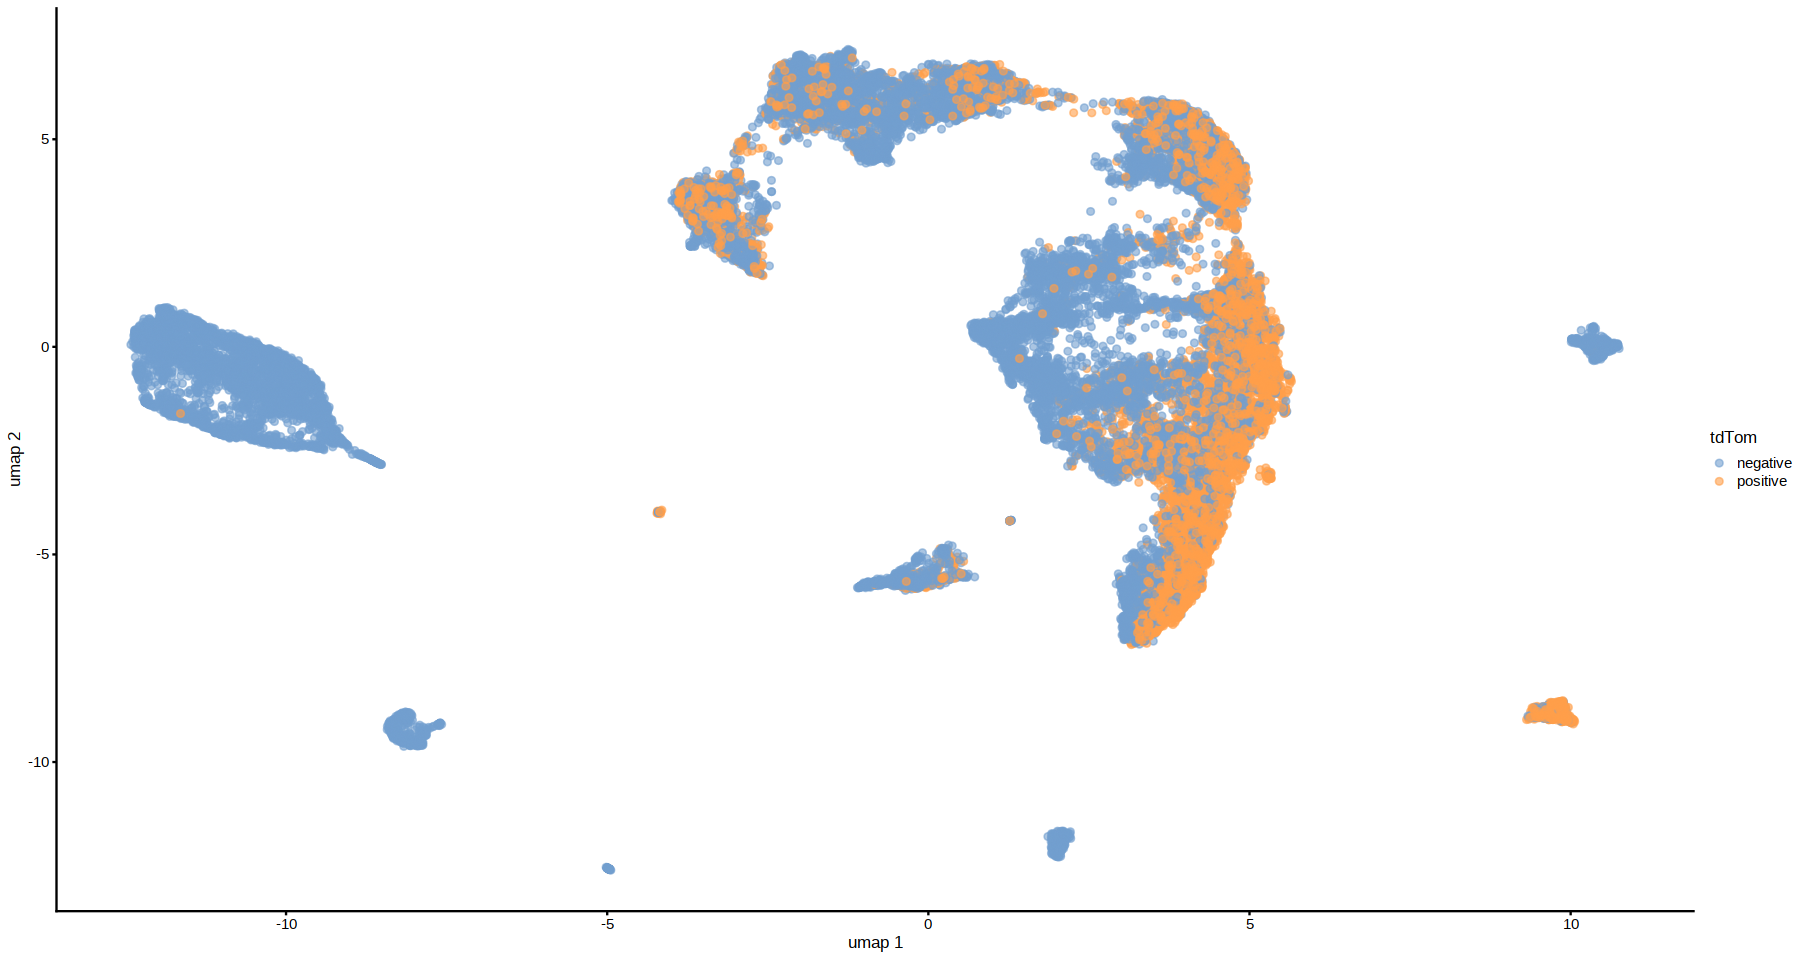

In [139]:
plotReducedDim(embryo_data, colour_by="tdTom", dimred = "umap") 

In [13]:
embryo_milo <- Milo(embryo_data)
embryo_milo

class: Milo 
dim: 29453 27776 
metadata(0):
assays(2): counts logcounts
rownames(29453): ENSMUSG00000051951 ENSMUSG00000089699 ...
  ENSMUSG00000095742 tomato-td
rowData names(0):
colnames(27776): cell_1 cell_2 ... cell_30169 cell_30171
colData names(21): barcode stage ... umapX.mapped umapY.mapped
reducedDimNames(2): pca.corrected umap
mainExpName: NULL
altExpNames(0):
nhoods dimensions(2): 1 1
nhoodCounts dimensions(2): 1 1
nhoodDistances dimension(1): 0
graph names(0):
nhoodIndex names(1): 0
nhoodExpression dimension(2): 1 1
nhoodReducedDim names(0):
nhoodGraph names(0):
nhoodAdjacency dimension(2): 1 1

In [14]:
embryo_milo <- buildGraph(embryo_milo, k = 30, d = 30, reduced.dim = "pca.corrected")

Constructing kNN graph with k:30



In [15]:
# lower prop for larger datasets
embryo_milo <- makeNhoods(embryo_milo, prop = 0.05, k = 30, d=30, refined = TRUE, reduced_dims = "pca.corrected")

Checking valid object



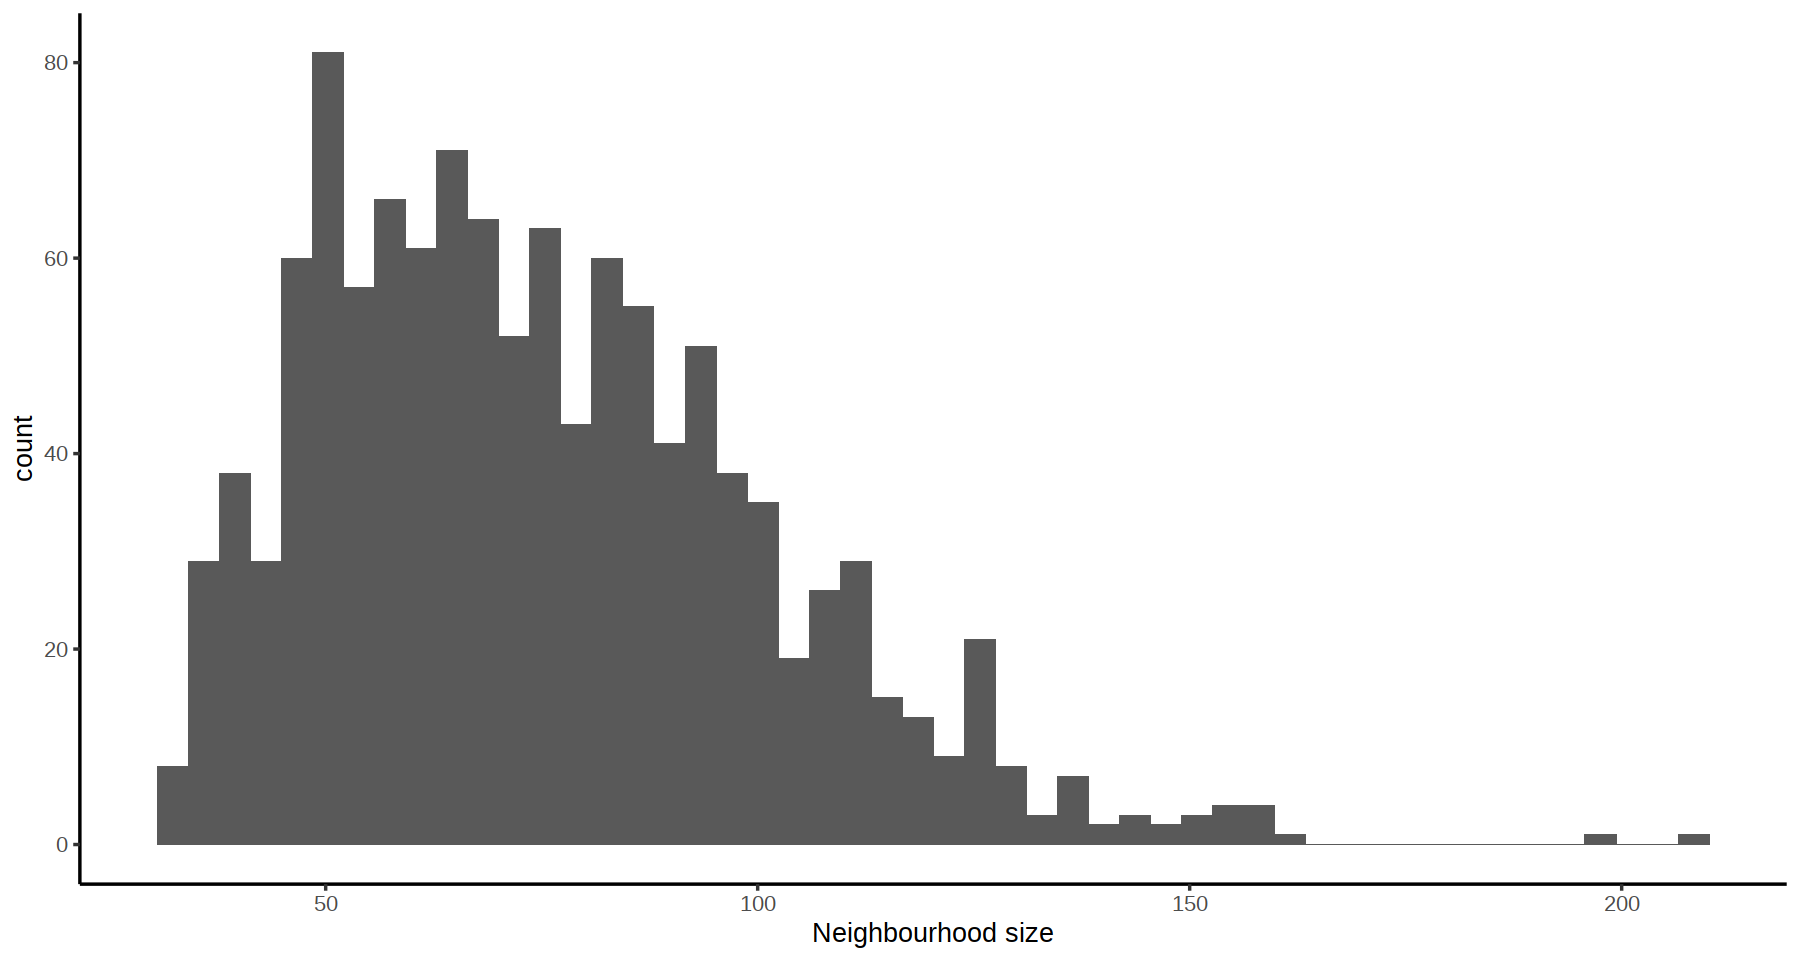

In [16]:
plotNhoodSizeHist(embryo_milo)

In [17]:
embryo_milo <- countCells(embryo_milo, meta.data = as.data.frame(colData(embryo_milo)), sample="sample")

Checking meta.data validity

Counting cells in neighbourhoods



In [18]:
head(nhoodCounts(embryo_milo))

6 x 8 sparse Matrix of class "dgCMatrix"
  3  8  4  5  1  6  2  7
1 1 10 21  4 21 38 28  1
2 .  1  4  3  5  . 25  .
3 .  1  3  7  8  4 13  1
4 1  2  1 44 42  5  7 15
5 5  3 21 14 17  3  8  8
6 7 19 15 13 23 11 28  .

In [19]:
colnames(colData(embryo_milo))

[1] "barcode"         "stage"           "batch"           "Sample_name"    
 [5] "batch_name"      "tdTom"           "index"           "sample"         
 [9] "doub.density"    "doublet"         "stripped"        "umap_1"         
[13] "umap_2"          "louvain_cluster" "celltype.mapped" "stage.mapped"   
[17] "closest.cell"    "celltype.score"  "cellstage.score" "umapX.mapped"   
[21] "umapY.mapped"

In [20]:
embryo_design <- data.frame(colData(embryo_milo))[,c("sample", "tdTom")]

## Convert batch info from integer to factor

embryo_design <- distinct(embryo_design)
rownames(embryo_design) <- embryo_design$sample

embryo_design

,sample,tdTom
,<int>,<chr>
3,3,positive
8,8,negative
4,4,negative
5,5,positive
1,1,positive
6,6,negative
2,2,negative
7,7,positive


In [21]:
embryo_milo <- calcNhoodDistance(embryo_milo, d=30, reduced.dim = "pca.corrected")

In [22]:
# design = what to test for, can correct for another variable as well
da_results <- testNhoods(embryo_milo, design = ~ tdTom, design.df = embryo_design, reduced.dim="pca.corrected")
head(da_results)

Using TMM normalisation

Performing spatial FDR correction withk-distance weighting



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-2.0692545,10.748234,10.1821604,0.0031978974,0.006362181,1,0.006141863
2,-1.7378785,9.234575,3.1965932,0.0836878226,0.117563851,2,0.116119932
3,-0.4341955,9.259746,0.2831399,0.5983722418,0.650501056,3,0.648689460
4,2.5453958,10.554501,13.8638168,0.0007668186,0.001813464,4,0.001720103
5,0.3637884,10.215446,0.3160739,0.5779433046,0.631805682,5,0.629858958
6,-0.9175801,10.699435,2.0402967,0.1629899991,0.209635163,6,0.207755005


In [23]:
da_results %>%
  arrange(SpatialFDR) %>%
  head() 

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
9,-8.072716,10.89103,56.11262,3.227212e-08,2.053715e-06,9,1.565154e-06
79,-8.165801,10.97474,58.89702,2.017470e-08,2.053715e-06,79,1.565154e-06
80,-7.628773,10.50698,54.47812,4.283635e-08,2.053715e-06,80,1.565154e-06
119,-7.817884,10.66709,56.51313,3.013434e-08,2.053715e-06,119,1.565154e-06
155,-8.491290,11.26529,53.22308,5.344896e-08,2.053715e-06,155,1.565154e-06
189,-8.007365,10.82887,54.08777,4.587224e-08,2.053715e-06,189,1.565154e-06


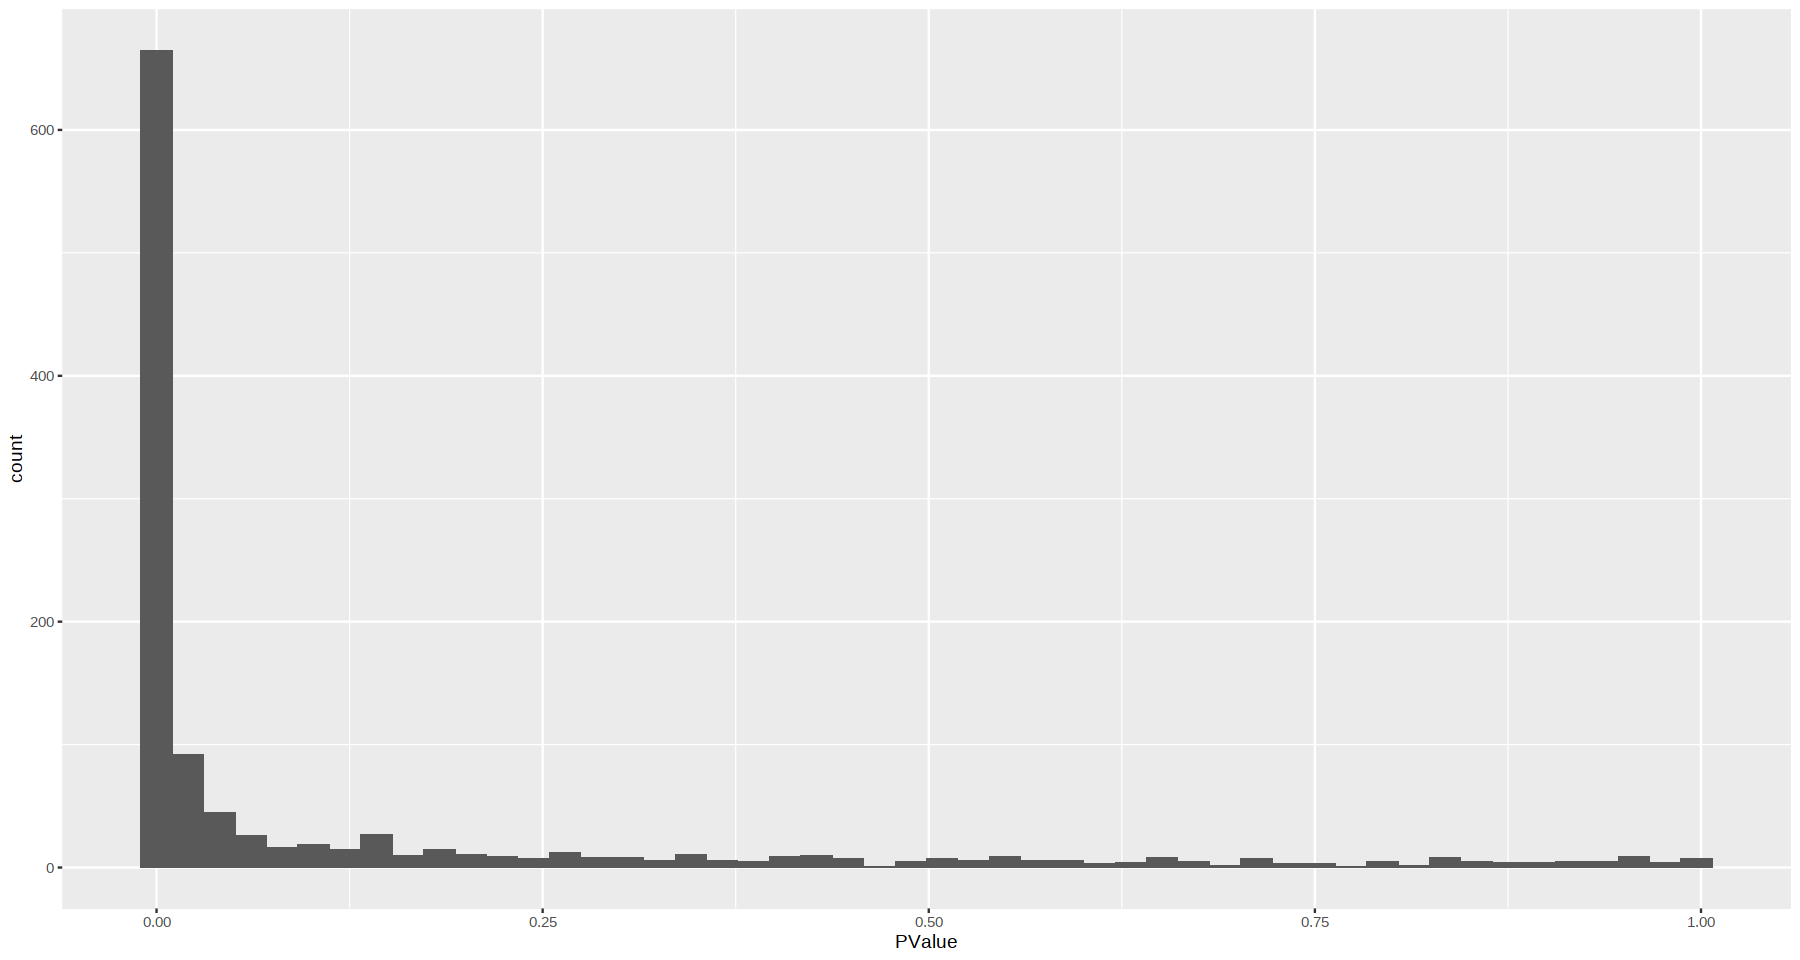

In [24]:
ggplot(da_results, aes(PValue)) + geom_histogram(bins=50)

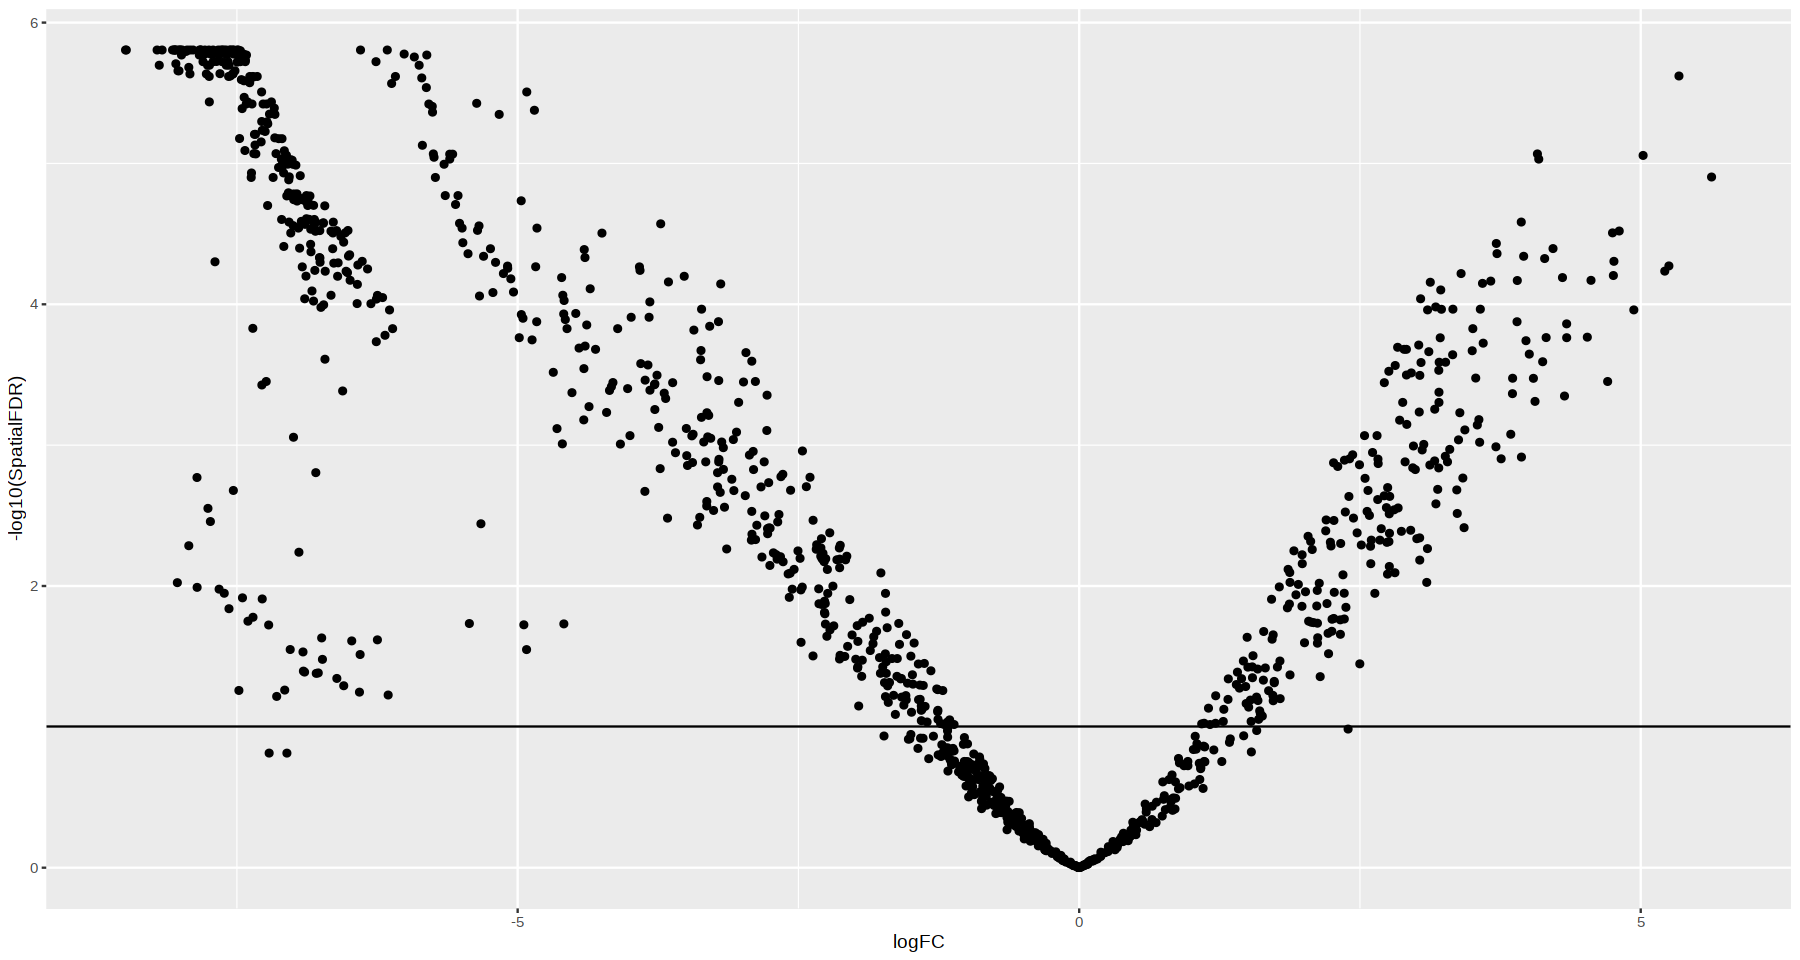

In [25]:
ggplot(da_results, aes(logFC, -log10(SpatialFDR))) + 
  geom_point() +
  geom_hline(yintercept = 1) ## Mark significance threshold (10% FDR)

In [26]:
options(repr.plot.width=15, repr.plot.height=8)

Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


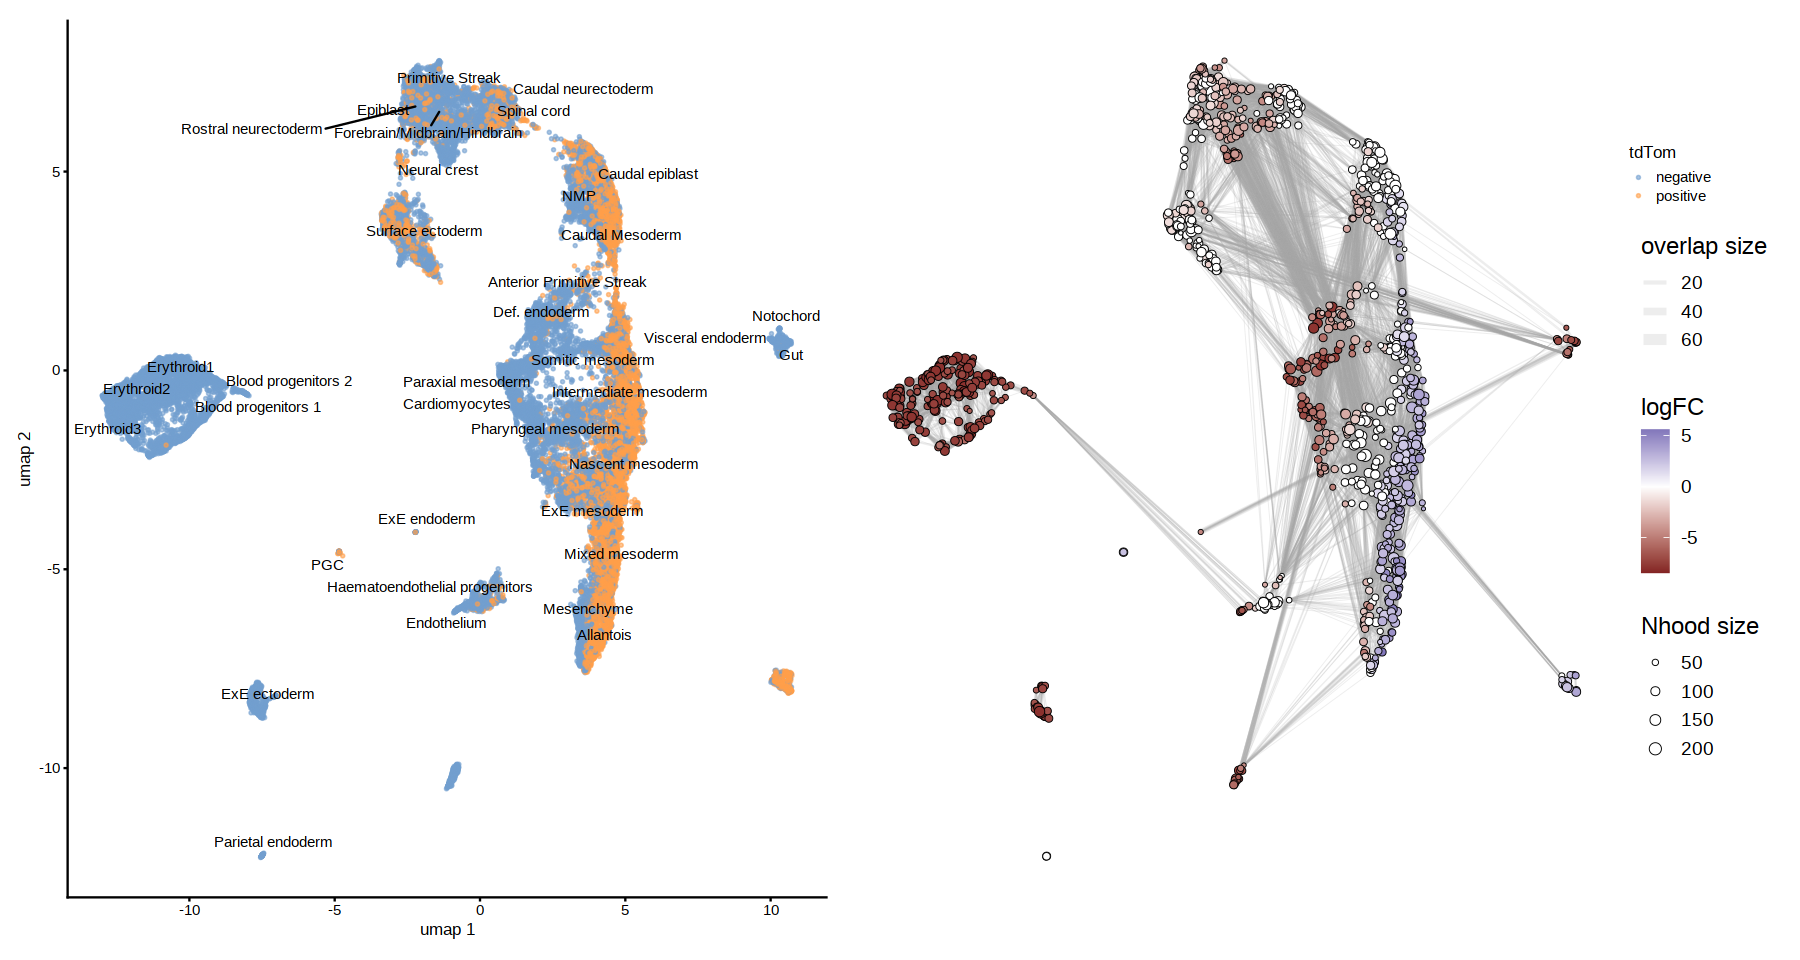

In [49]:
embryo_milo <- buildNhoodGraph(embryo_milo)

## Plot single-cell UMAP
umap_pl <- plotReducedDim(embryo_milo, dimred = "umap", colour_by="tdTom", text_by = "celltype.mapped", 
                          text_size = 3, point_size=0.5) +
  guides(fill="none")

## Plot neighbourhood graph
nh_graph_pl <- plotNhoodGraphDA(embryo_milo, da_results, layout="umap",alpha=0.1) 
  
umap_pl + nh_graph_pl +
  plot_layout(guides="collect")

In [28]:
da_results <- annotateNhoods(embryo_milo, da_results, coldata_col = "celltype.mapped")
head(da_results)

Converting celltype.mapped to factor...



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,celltype.mapped,celltype.mapped_fraction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,-2.0692545,10.748234,10.1821604,0.0031978974,0.006362181,1,0.006141863,Rostral neurectoderm,0.6370968
2,-1.7378785,9.234575,3.1965932,0.0836878226,0.117563851,2,0.116119932,Haematoendothelial progenitors,0.7368421
3,-0.4341955,9.259746,0.2831399,0.5983722418,0.650501056,3,0.648689460,ExE mesoderm,0.2162162
4,2.5453958,10.554501,13.8638168,0.0007668186,0.001813464,4,0.001720103,ExE mesoderm,0.9145299
5,0.3637884,10.215446,0.3160739,0.5779433046,0.631805682,5,0.629858958,Caudal epiblast,0.9746835
6,-0.9175801,10.699435,2.0402967,0.1629899991,0.209635163,6,0.207755005,Rostral neurectoderm,0.7672414


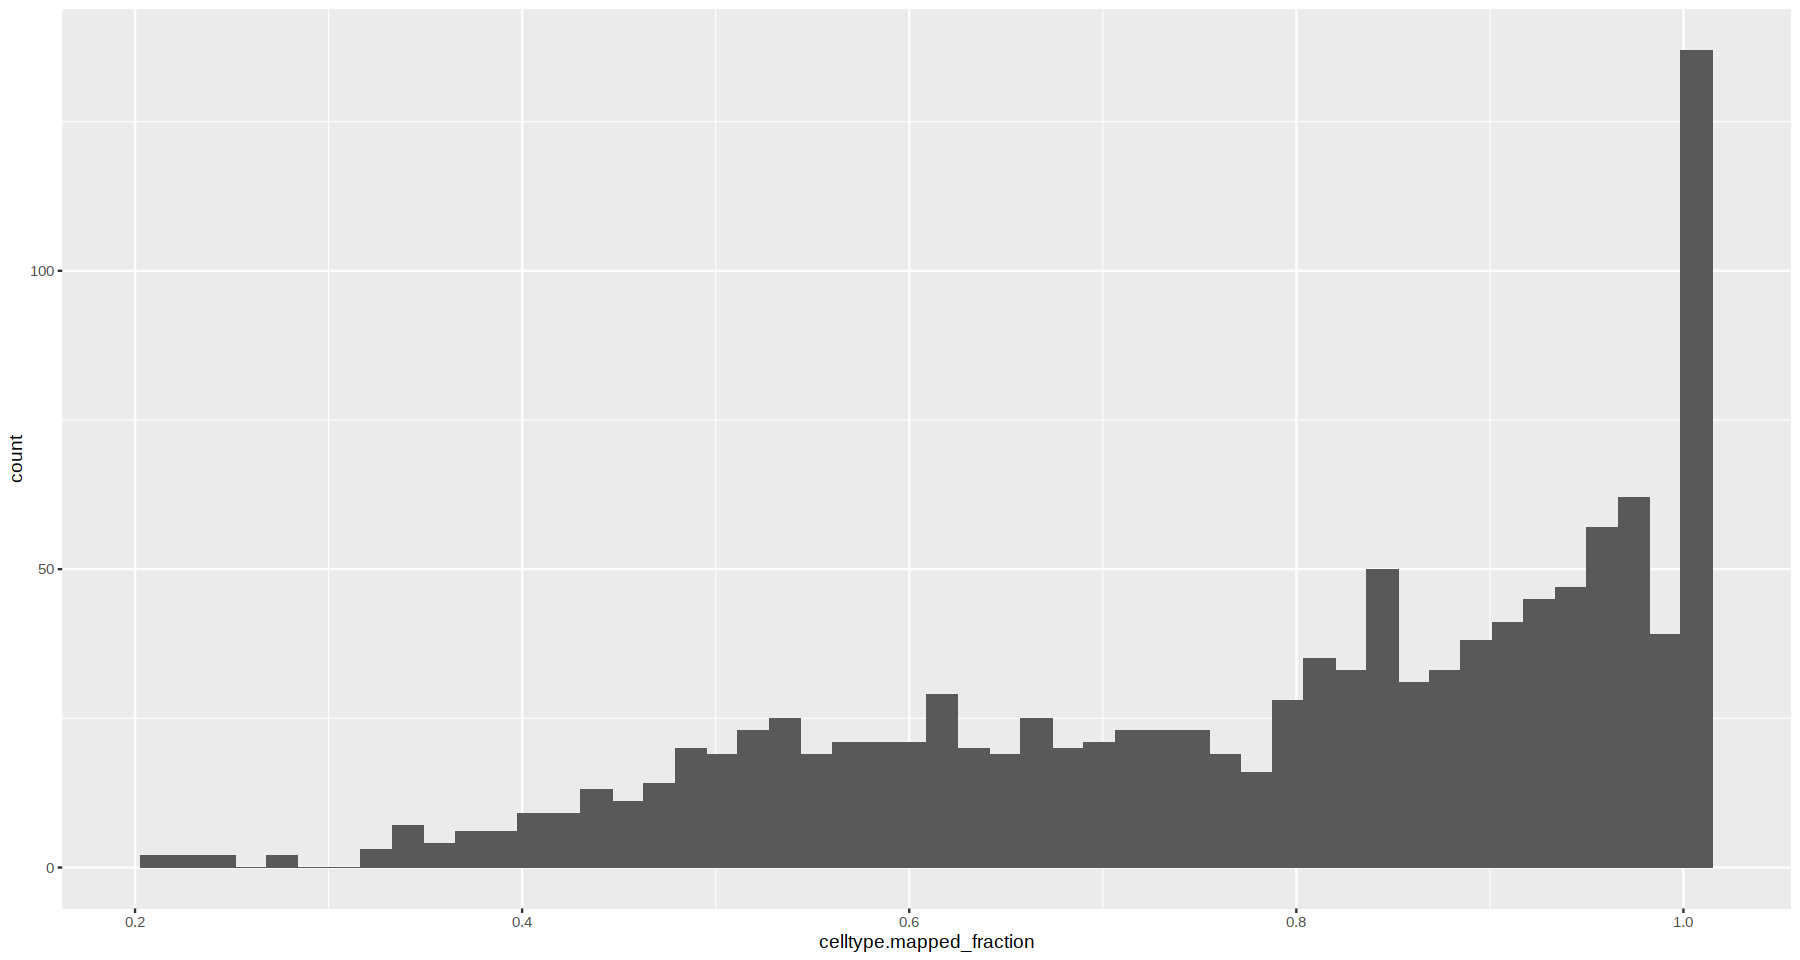

In [29]:
ggplot(da_results, aes(celltype.mapped_fraction)) + geom_histogram(bins=50)

In [30]:
da_results$celltype.mapped <- ifelse(da_results$celltype.mapped_fraction < 0.7, "Mixed", da_results$celltype.mapped)


Converting group.by to factor...



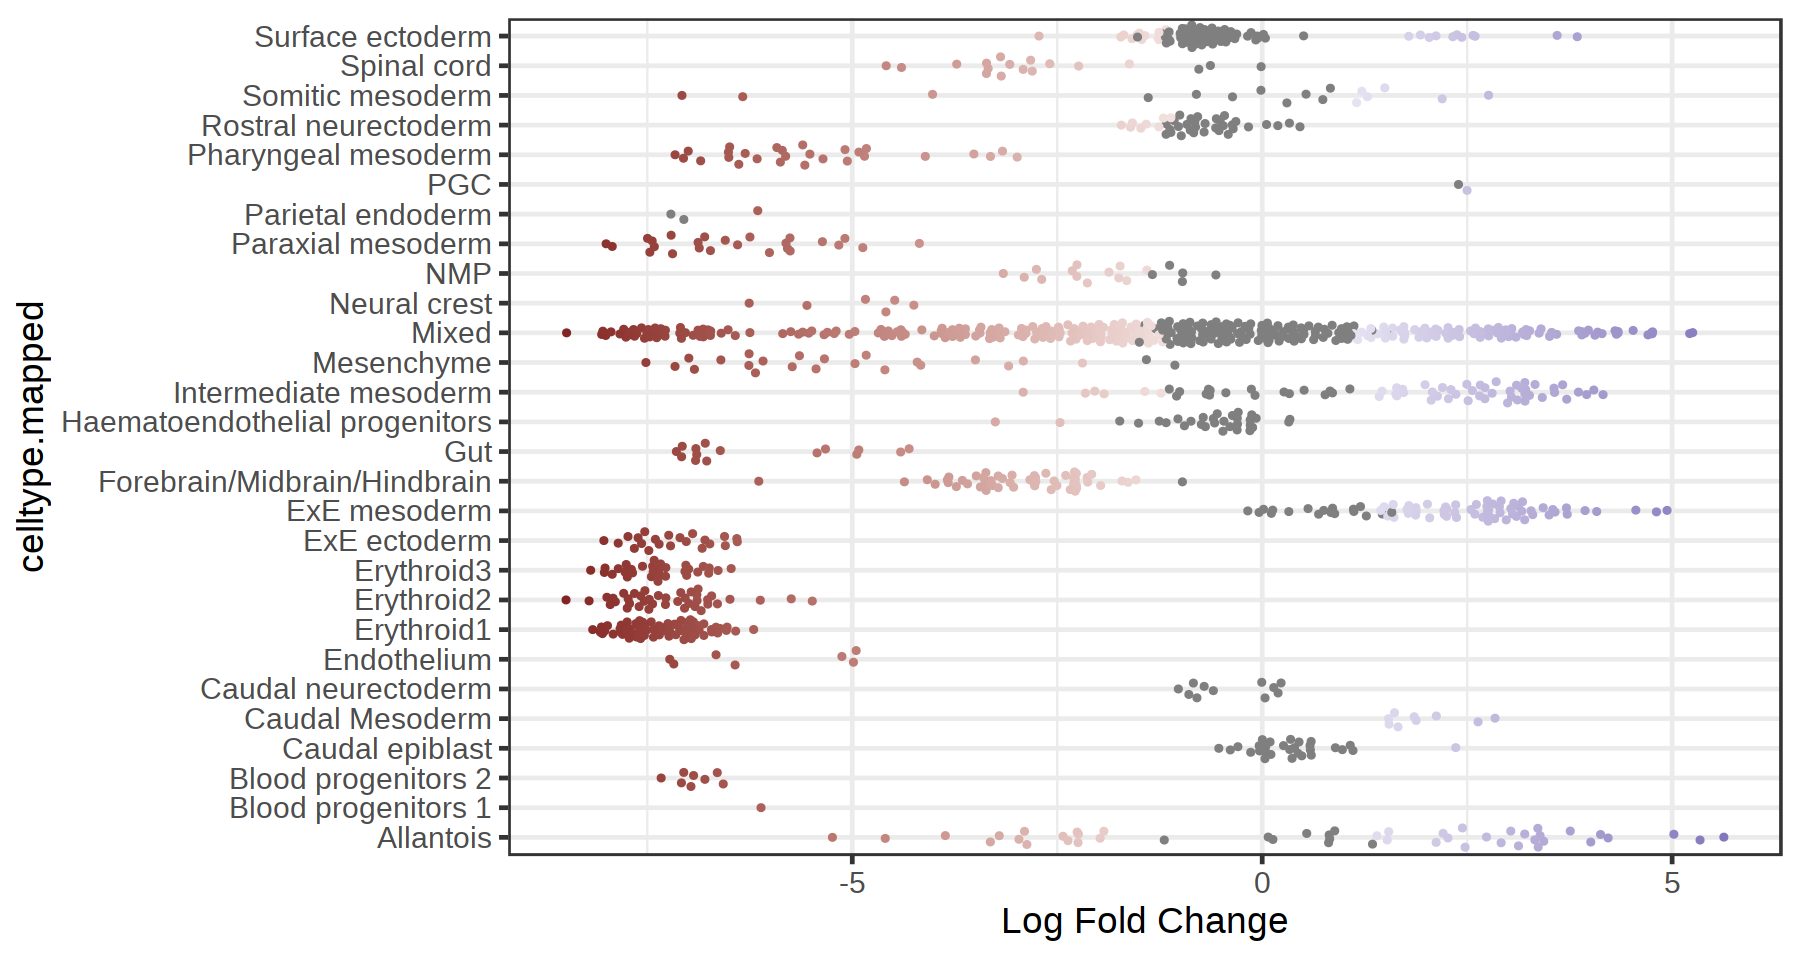

In [31]:
plotDAbeeswarm(da_results, group.by = "celltype.mapped")


In [32]:
## Add log normalized count to Milo object
embryo_milo <- logNormCounts(embryo_milo)

da_results$NhoodGroup <- as.numeric(da_results$SpatialFDR < 0.1 & da_results$logFC < 0)
da_nhood_markers <- findNhoodGroupMarkers(embryo_milo, da_results, subset.row = rownames(embryo_milo)[1:10])

Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”


In [33]:
head(da_nhood_markers)

,logFC_1,adj.P.Val_1,logFC_0,adj.P.Val_0,GeneID
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUSG00000033845,0.107647046,1.276285e-22,-0.107647046,1.276285e-22,ENSMUSG00000033845
ENSMUSG00000025903,0.022340887,5.226849e-04,-0.022340887,5.226849e-04,ENSMUSG00000025903
ENSMUSG00000025900,0.001970812,1.536419e-03,-0.001970812,1.536419e-03,ENSMUSG00000025900
ENSMUSG00000025902,-0.012710514,1.302070e-02,0.012710514,1.302070e-02,ENSMUSG00000025902
ENSMUSG00000051951,-0.001981541,1.131355e-01,0.001981541,1.131355e-01,ENSMUSG00000051951
ENSMUSG00000033813,0.014476404,2.533690e-01,-0.014476404,2.533690e-01,ENSMUSG00000033813


In [34]:
da_nhood_markers <- findNhoodGroupMarkers(embryo_milo, da_results, subset.row = rownames(embryo_milo)[1:10], 
                                          aggregate.samples = TRUE, sample_col = "sample")

Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”


In [35]:
head(da_nhood_markers)

,logFC_1,adj.P.Val_1,logFC_0,adj.P.Val_0,GeneID
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUSG00000033813,-0.0670173060,0.1531987,0.0670173060,0.1531987,ENSMUSG00000033813
ENSMUSG00000025902,-0.0477754099,0.1531987,0.0477754099,0.1531987,ENSMUSG00000025902
ENSMUSG00000051951,-0.0050121787,0.1531987,0.0050121787,0.1531987,ENSMUSG00000051951
ENSMUSG00000104217,-0.0009453885,0.1774913,0.0009453885,0.1774913,ENSMUSG00000104217
ENSMUSG00000089699,0.0001057738,0.2567965,-0.0001057738,0.2567965,ENSMUSG00000089699
ENSMUSG00000025900,0.0008312050,0.2585234,-0.0008312050,0.2585234,ENSMUSG00000025900


In [36]:
## Run buildNhoodGraph to store nhood adjacency matrix
embryo_milo <- buildNhoodGraph(embryo_milo)

## Find groups
da_results <- groupNhoods(embryo_milo, da_results, max.lfc.delta = 10)
head(da_results)

Found 828 DA neighbourhoods at FDR 10%

nhoodAdjacency found - using for nhood grouping



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,celltype.mapped,celltype.mapped_fraction,NhoodGroup
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,-2.0692545,10.748234,10.1821604,0.0031978974,0.006362181,1,0.006141863,Mixed,0.6370968,1
2,-1.7378785,9.234575,3.1965932,0.0836878226,0.117563851,2,0.116119932,Haematoendothelial progenitors,0.7368421,2
3,-0.4341955,9.259746,0.2831399,0.5983722418,0.650501056,3,0.648689460,Mixed,0.2162162,3
4,2.5453958,10.554501,13.8638168,0.0007668186,0.001813464,4,0.001720103,ExE mesoderm,0.9145299,4
5,0.3637884,10.215446,0.3160739,0.5779433046,0.631805682,5,0.629858958,Caudal epiblast,0.9746835,5
6,-0.9175801,10.699435,2.0402967,0.1629899991,0.209635163,6,0.207755005,Rostral neurectoderm,0.7672414,1


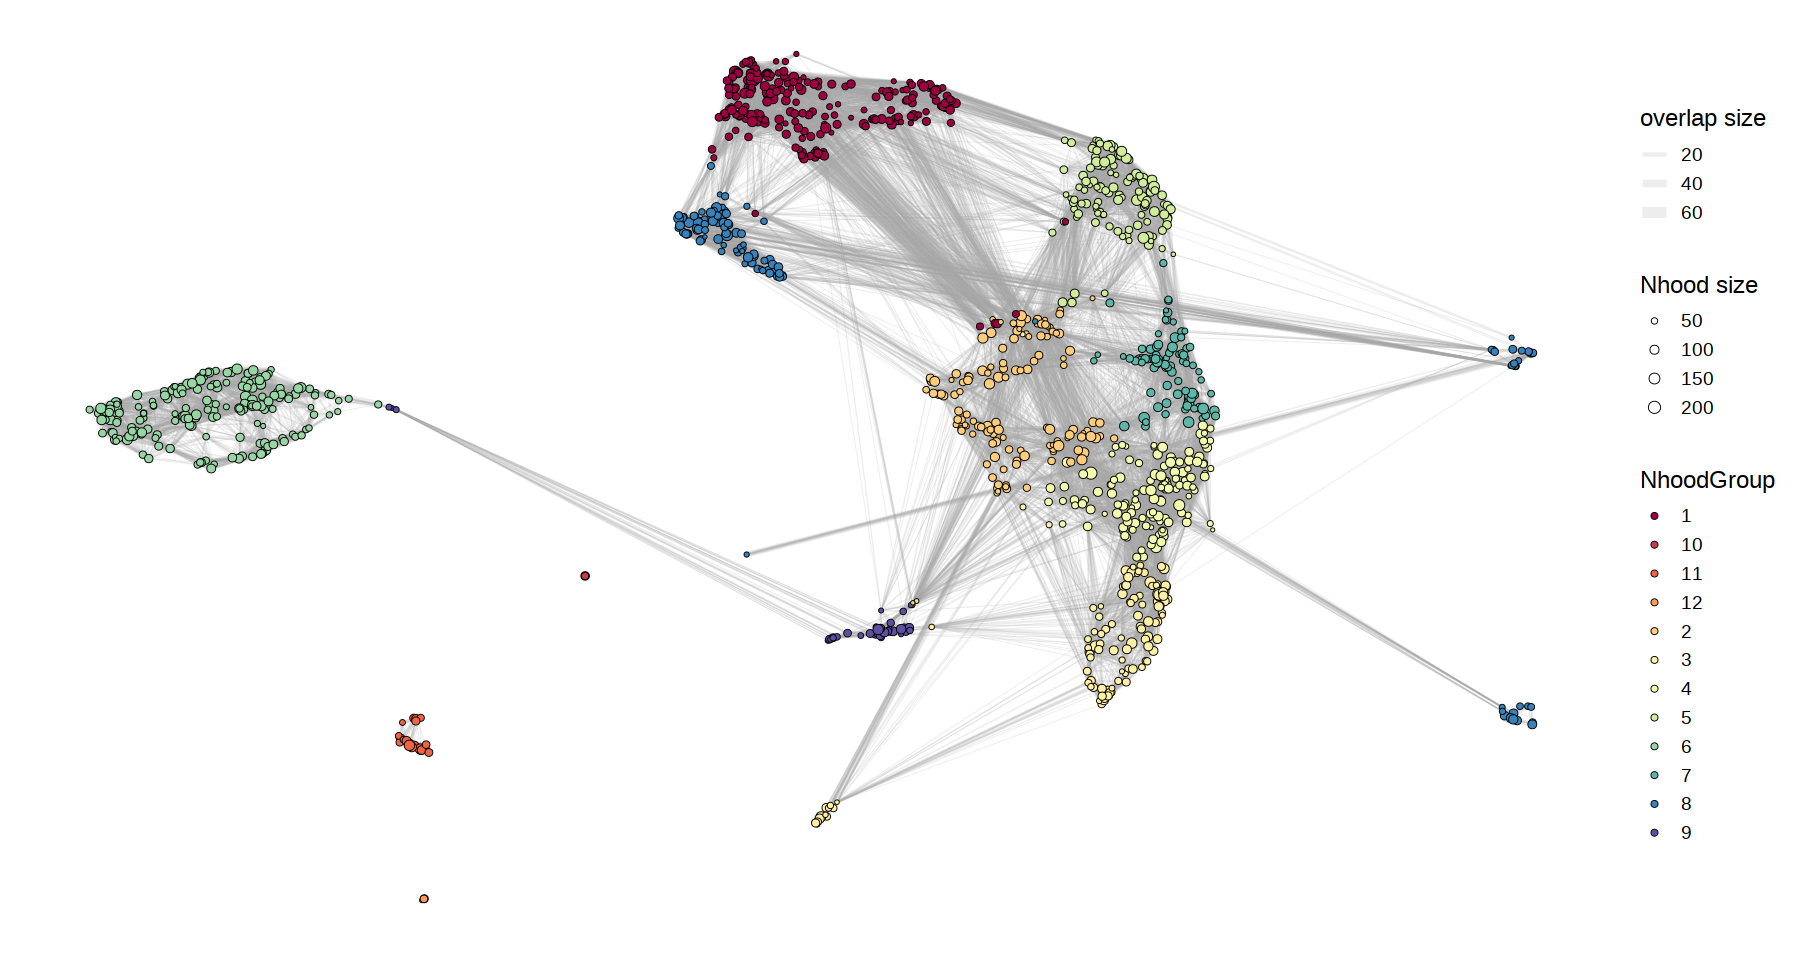

In [37]:
plotNhoodGroups(embryo_milo, da_results, layout="umap") 

Converting group.by to factor...



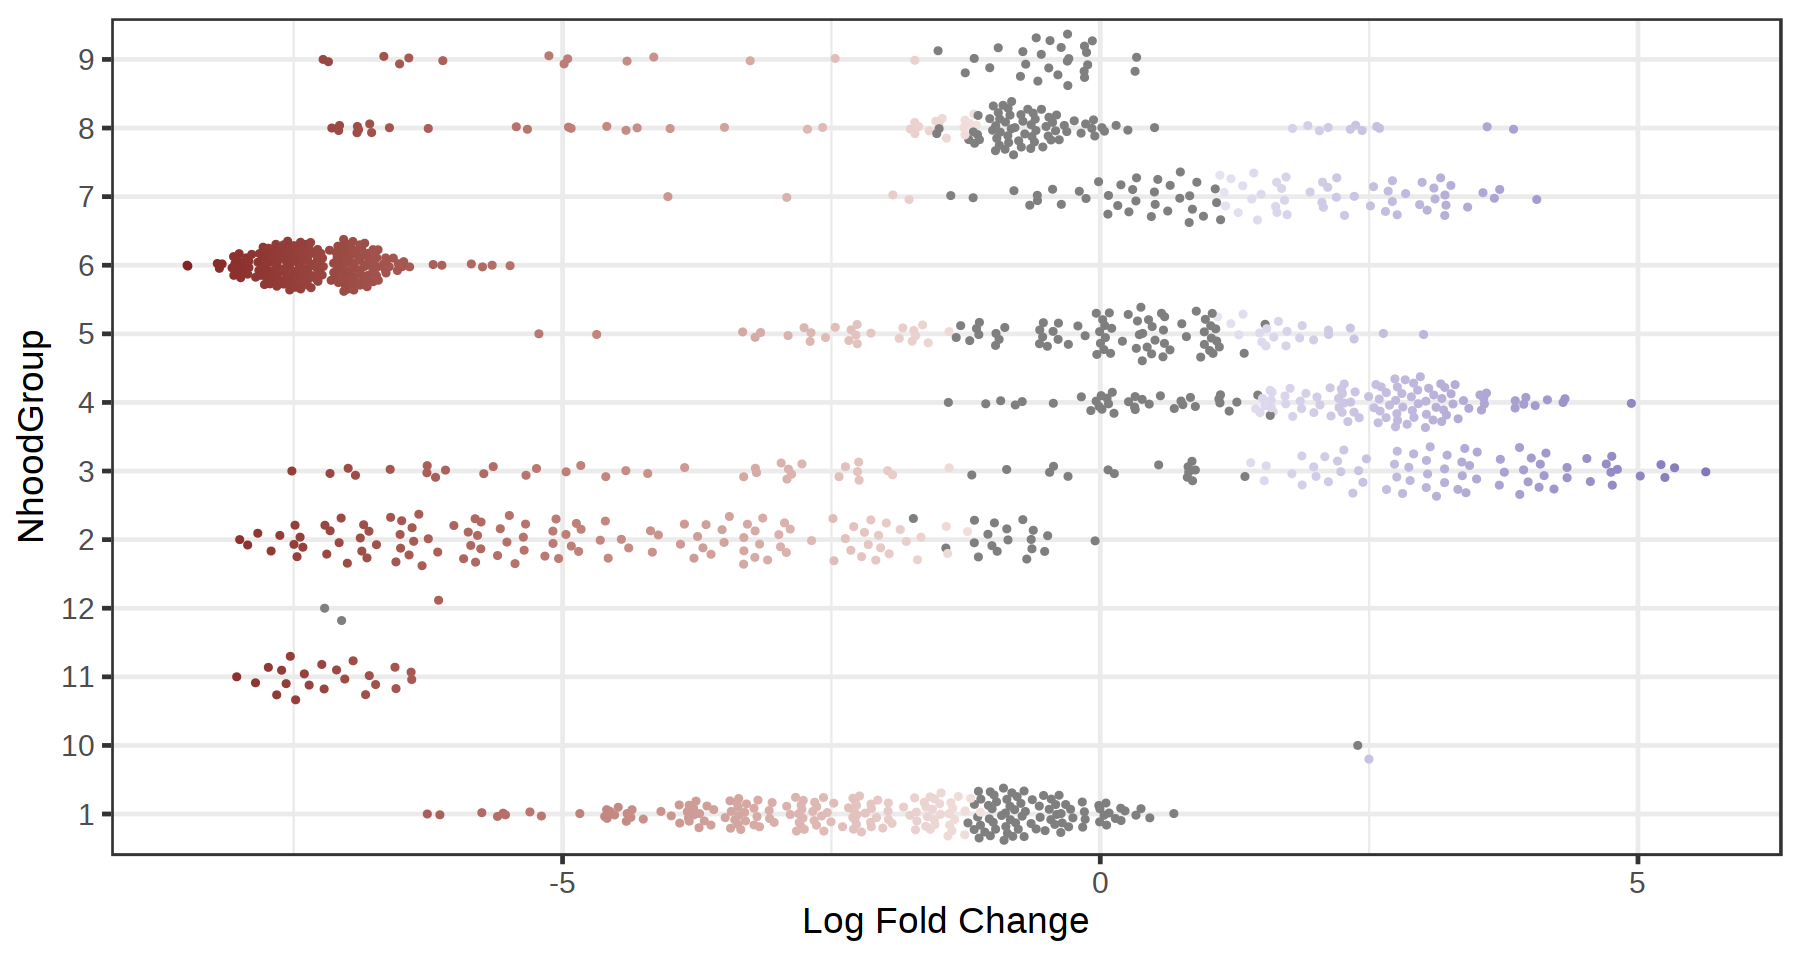

In [38]:
plotDAbeeswarm(da_results, "NhoodGroup")

Found 828 DA neighbourhoods at FDR 10%

nhoodAdjacency found - using for nhood grouping



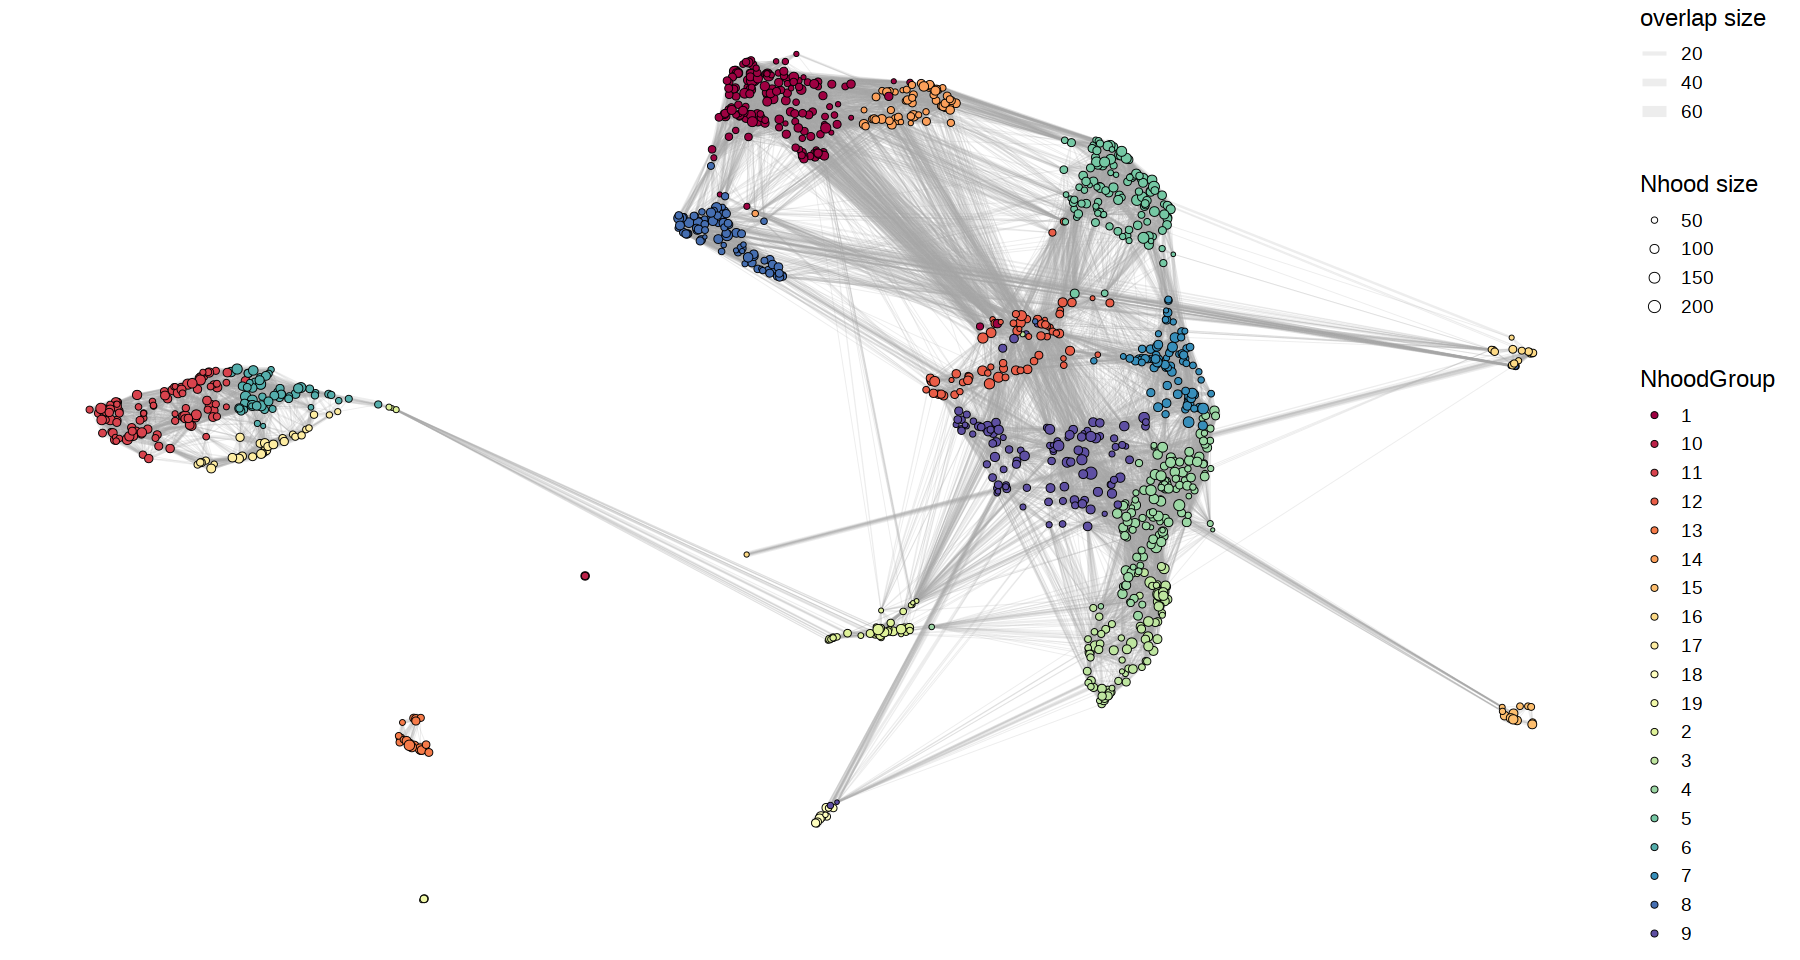

In [39]:
set.seed(42)
da_results <- groupNhoods(embryo_milo, da_results, max.lfc.delta = 5, overlap=5)
plotNhoodGroups(embryo_milo, da_results, layout="umap")

Converting group.by to factor...



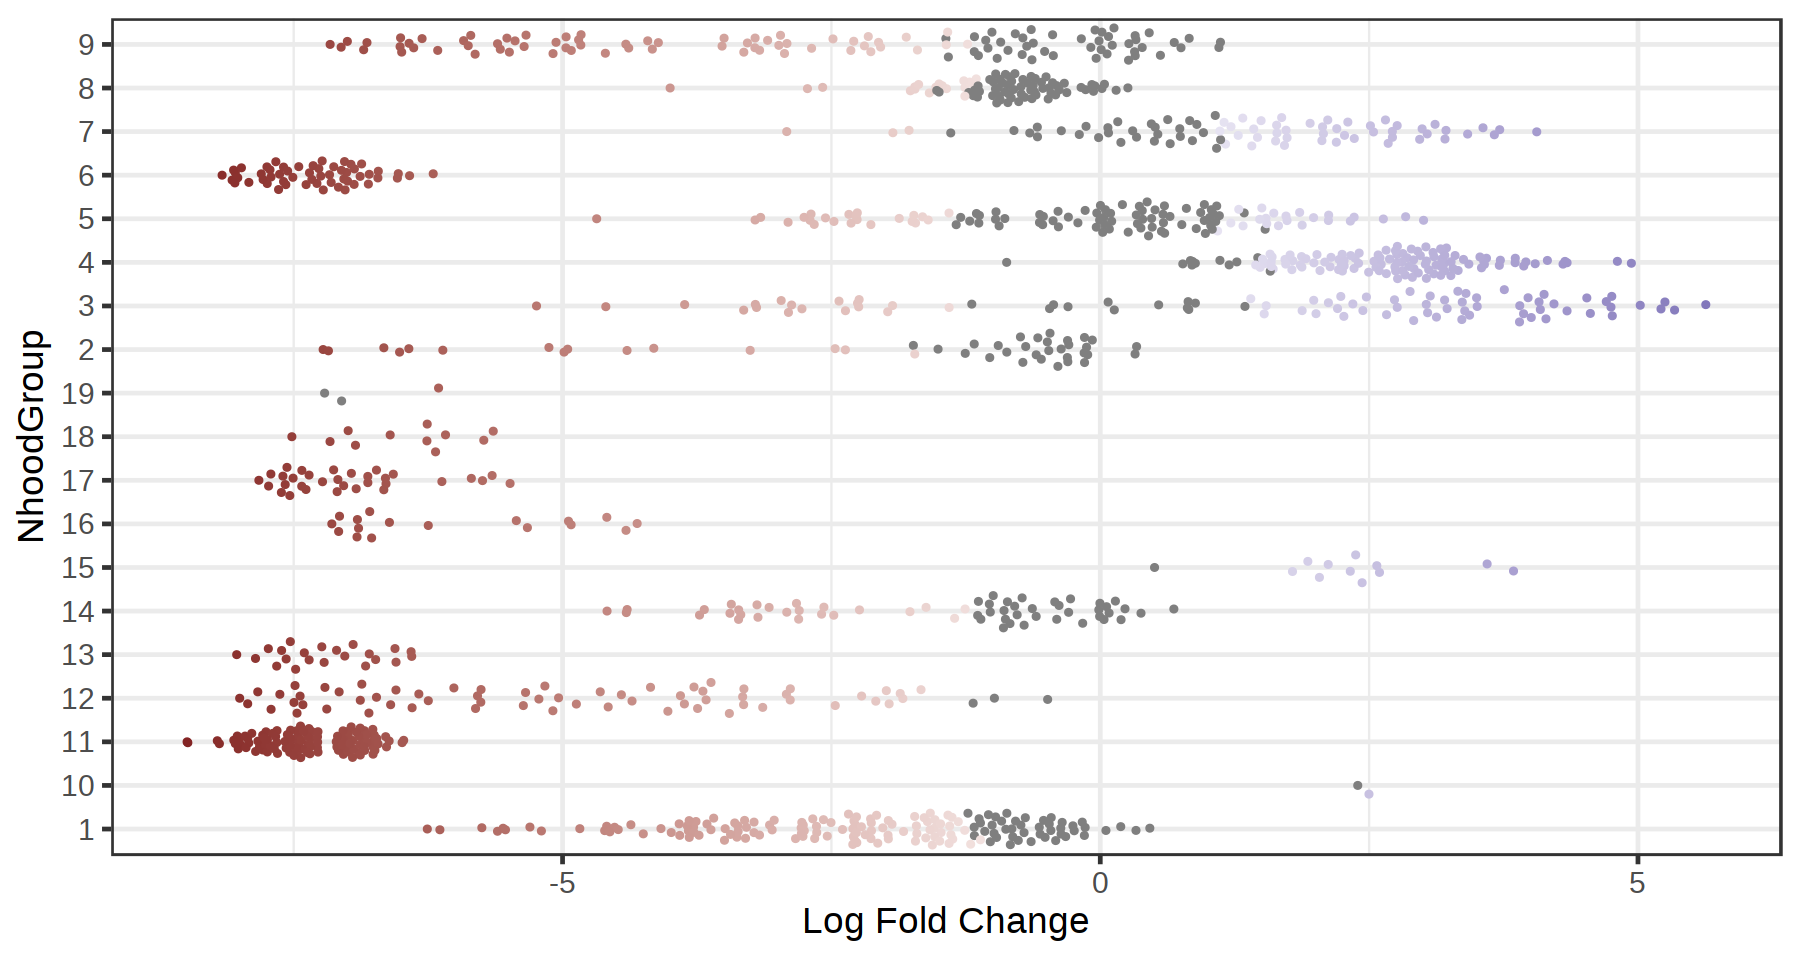

In [40]:
plotDAbeeswarm(da_results, group.by = "NhoodGroup")

In [41]:
## Exclude zero counts genes
keep.rows <- rowSums(logcounts(embryo_milo)) != 0
embryo_milo <- embryo_milo[keep.rows, ]

## Find HVGs
set.seed(101)
dec <- modelGeneVar(embryo_milo)
hvgs <- getTopHVGs(dec, n=2000)
head(hvgs)

[1] "ENSMUSG00000055609" "ENSMUSG00000052217" "ENSMUSG00000052187"
[4] "ENSMUSG00000069919" "ENSMUSG00000000031" "ENSMUSG00000002265"

In [42]:
set.seed(42)
nhood_markers <- findNhoodGroupMarkers(embryo_milo, da_results, subset.row = hvgs, 
                                       aggregate.samples = TRUE, sample_col = "sample")

head(nhood_markers)

,logFC_1,adj.P.Val_1,logFC_2,adj.P.Val_2,logFC_3,adj.P.Val_3,logFC_4,adj.P.Val_4,logFC_5,adj.P.Val_5,⋯,adj.P.Val_15,logFC_16,adj.P.Val_16,logFC_17,adj.P.Val_17,logFC_18,adj.P.Val_18,logFC_19,adj.P.Val_19,GeneID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUSG00000058665,0.4409873,2.827871e-61,0.9159294,2.201508e-69,0.5213930,1.105873e-39,0.7160648,2.626149e-25,1.2925989,6.151829e-44,⋯,6.362313e-44,0.9082724,9.476676e-40,0.8446305,1.978686e-15,4.3734912,1.114894e-58,4.104541,1.128514e-111,ENSMUSG00000058665
ENSMUSG00000040726,0.5019720,2.718935e-58,1.1701426,2.995829e-62,1.4591949,1.556735e-37,0.8525701,3.699593e-14,1.7765283,4.271491e-35,⋯,7.759363e-44,0.8072829,2.194169e-36,0.4563623,1.978686e-15,0.9489240,7.393220e-56,4.819761,1.026015e-98,ENSMUSG00000040726
ENSMUSG00000029595,0.4706312,4.171899e-56,2.3093831,2.384304e-61,0.4919629,3.396666e-31,0.6864994,4.875877e-13,1.9923826,2.888199e-25,⋯,1.012986e-40,3.2491183,3.493180e-33,0.7112977,1.978686e-15,1.3455694,3.594350e-52,2.006426,3.197143e-81,ENSMUSG00000029595
ENSMUSG00000024518,0.2379526,2.060563e-44,2.2714502,1.792958e-59,0.5047419,2.777677e-29,1.3622340,6.705653e-13,2.1421724,3.236231e-18,⋯,4.131883e-36,2.2236625,7.042094e-32,1.2814300,1.978686e-15,1.3904605,2.514308e-49,2.671861,7.085684e-73,ENSMUSG00000024518
ENSMUSG00000054667,0.4269706,4.624753e-38,1.2494643,4.908756e-52,0.4814842,1.184861e-26,1.1559696,6.749300e-12,1.4736648,3.236231e-18,⋯,1.238074e-32,0.4343532,1.164898e-28,1.3011576,3.064808e-15,0.8475994,4.536069e-40,4.550474,3.165228e-65,ENSMUSG00000054667
ENSMUSG00000038805,0.6363424,2.388723e-36,0.9709340,9.293942e-51,2.1220134,2.876213e-26,0.6098360,1.643354e-11,0.5368587,4.490188e-16,⋯,5.888006e-28,1.7700168,4.435043e-23,1.1522114,3.821999e-15,3.3032168,5.186824e-39,2.609407,8.303330e-59,ENSMUSG00000038805


In [43]:
gr5_markers <- nhood_markers[c("logFC_5", "adj.P.Val_5")] 
colnames(gr5_markers) <- c("logFC", "adj.P.Val")

head(gr5_markers[order(gr5_markers$adj.P.Val), ])

,logFC,adj.P.Val
,<dbl>,<dbl>
ENSMUSG00000058665,1.2925989,6.151829e-44
ENSMUSG00000040726,1.7765283,4.271491e-35
ENSMUSG00000029595,1.9923826,2.888199e-25
ENSMUSG00000024518,2.1421724,3.236231e-18
ENSMUSG00000054667,1.4736648,3.236231e-18
ENSMUSG00000038805,0.5368587,4.490188e-16


In [44]:
nhood_markers <- findNhoodGroupMarkers(embryo_milo, da_results, subset.row = hvgs, 
                                       aggregate.samples = TRUE, sample_col = "sample",
                                       subset.groups = c("5")
                                       )

Warning message in all(structure(c(1.29259889935037, 1.77652831860804, 1.99238262185043, :
“coercing argument of type 'double' to logical”


In [45]:
nhood_markers <- findNhoodGroupMarkers(embryo_milo, da_results, subset.row = hvgs,
                                       subset.nhoods = da_results$NhoodGroup %in% c('5','6'),
                                       aggregate.samples = TRUE, sample_col = "sample")

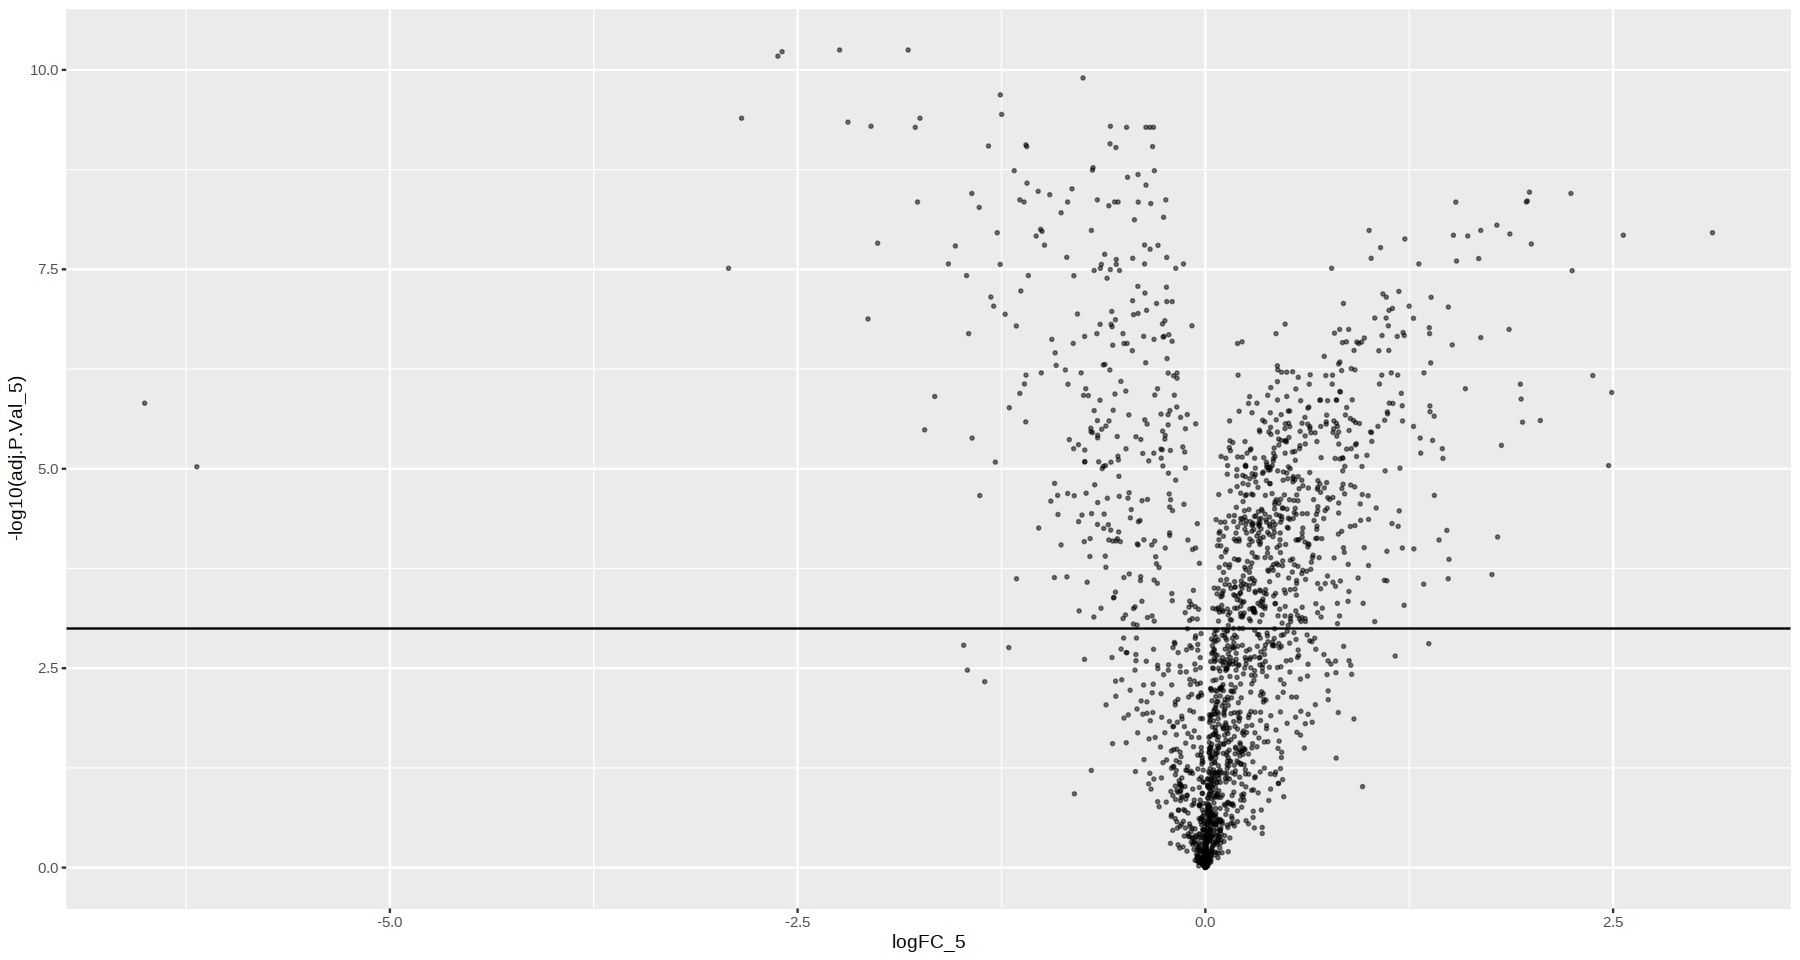

In [46]:
ggplot(nhood_markers, aes(logFC_5, -log10(adj.P.Val_5 ))) + 
  geom_point(alpha=0.5, size=0.5) +
  geom_hline(yintercept = 3)

In [47]:
markers <- rownames(nhood_markers)[nhood_markers$adj.P.Val_5 < 0.01 & nhood_markers$logFC_5 > 0]


Warning message in plotNhoodExpressionGroups(embryo_milo, da_results, features = intersect(rownames(embryo_milo), :
“Nothing in nhoodExpression(x): computing for requested features...”


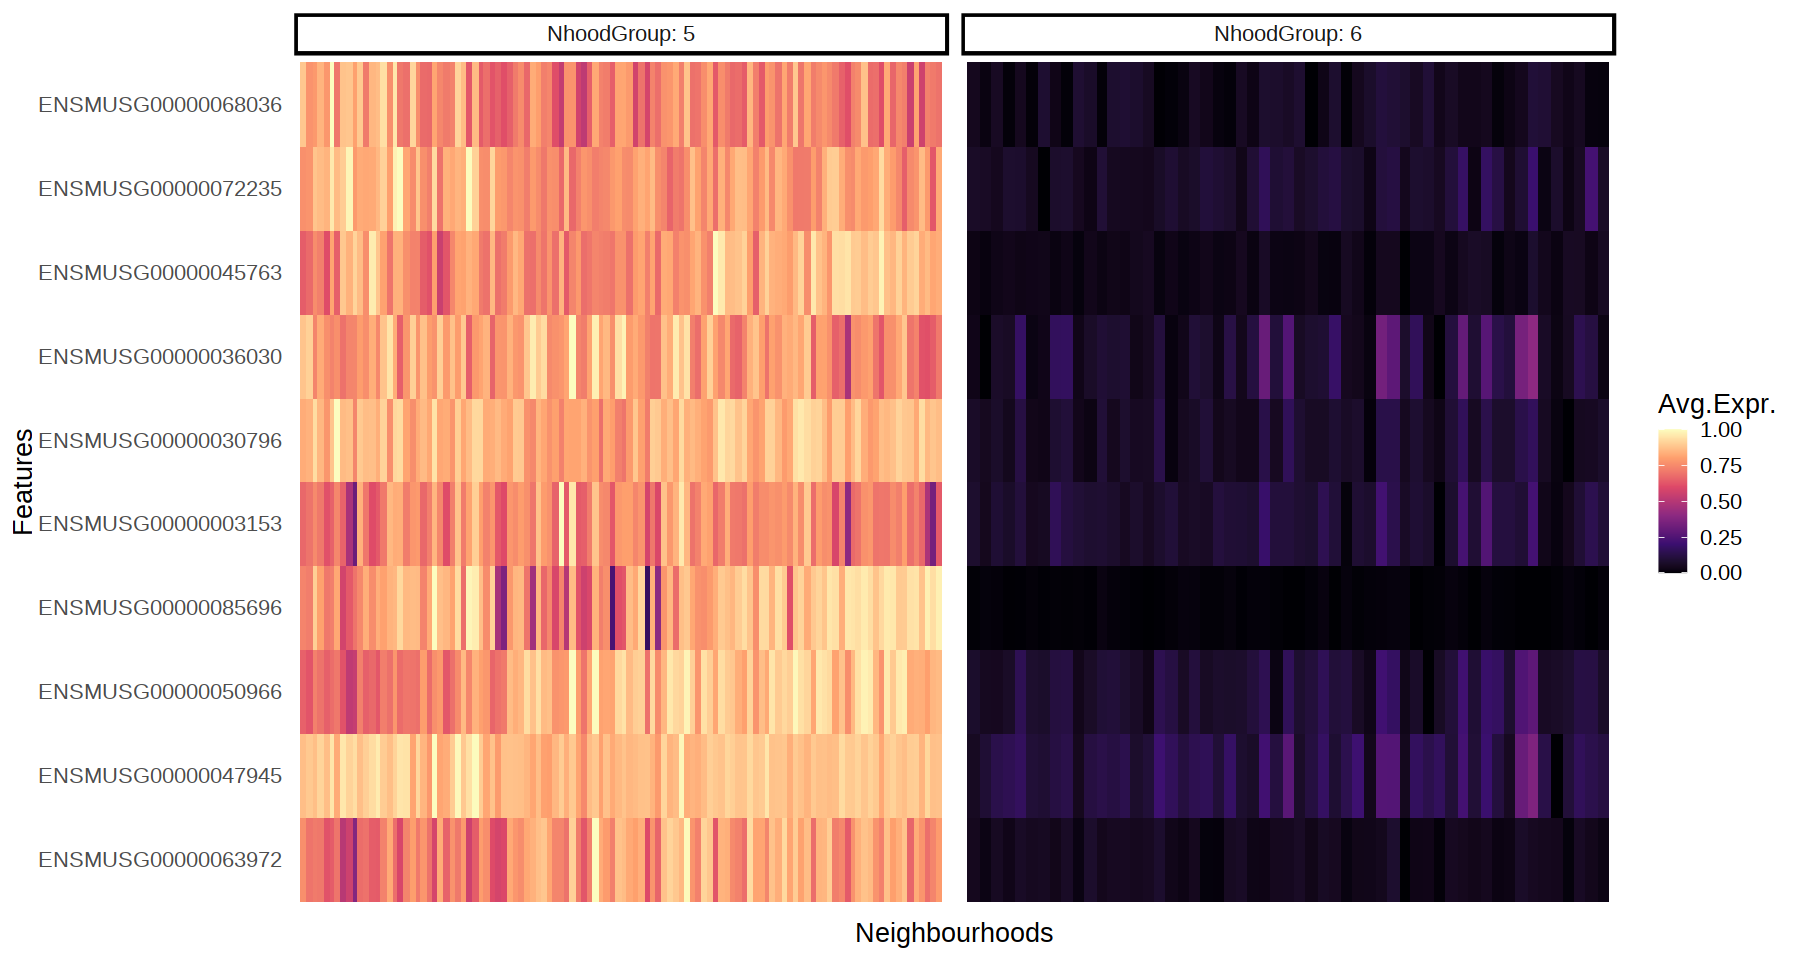

In [48]:
set.seed(42)
plotNhoodExpressionGroups(embryo_milo, da_results, features=intersect(rownames(embryo_milo), markers[1:10]),
                          subset.nhoods = da_results$NhoodGroup %in% c('6','5'), 
                          scale=TRUE,
                          grid.space = "fixed")

In [54]:
umap_mapped = colData(embryo_milo)[,c('umapX.mapped', 'umapY.mapped')]
reducedDims(embryo_milo) <- list(umap_mapped=umap_mapped)

Warning message in plotNhoodGraph(x, colour_by = res_column, ...):
“Coercing layout to matrix format”


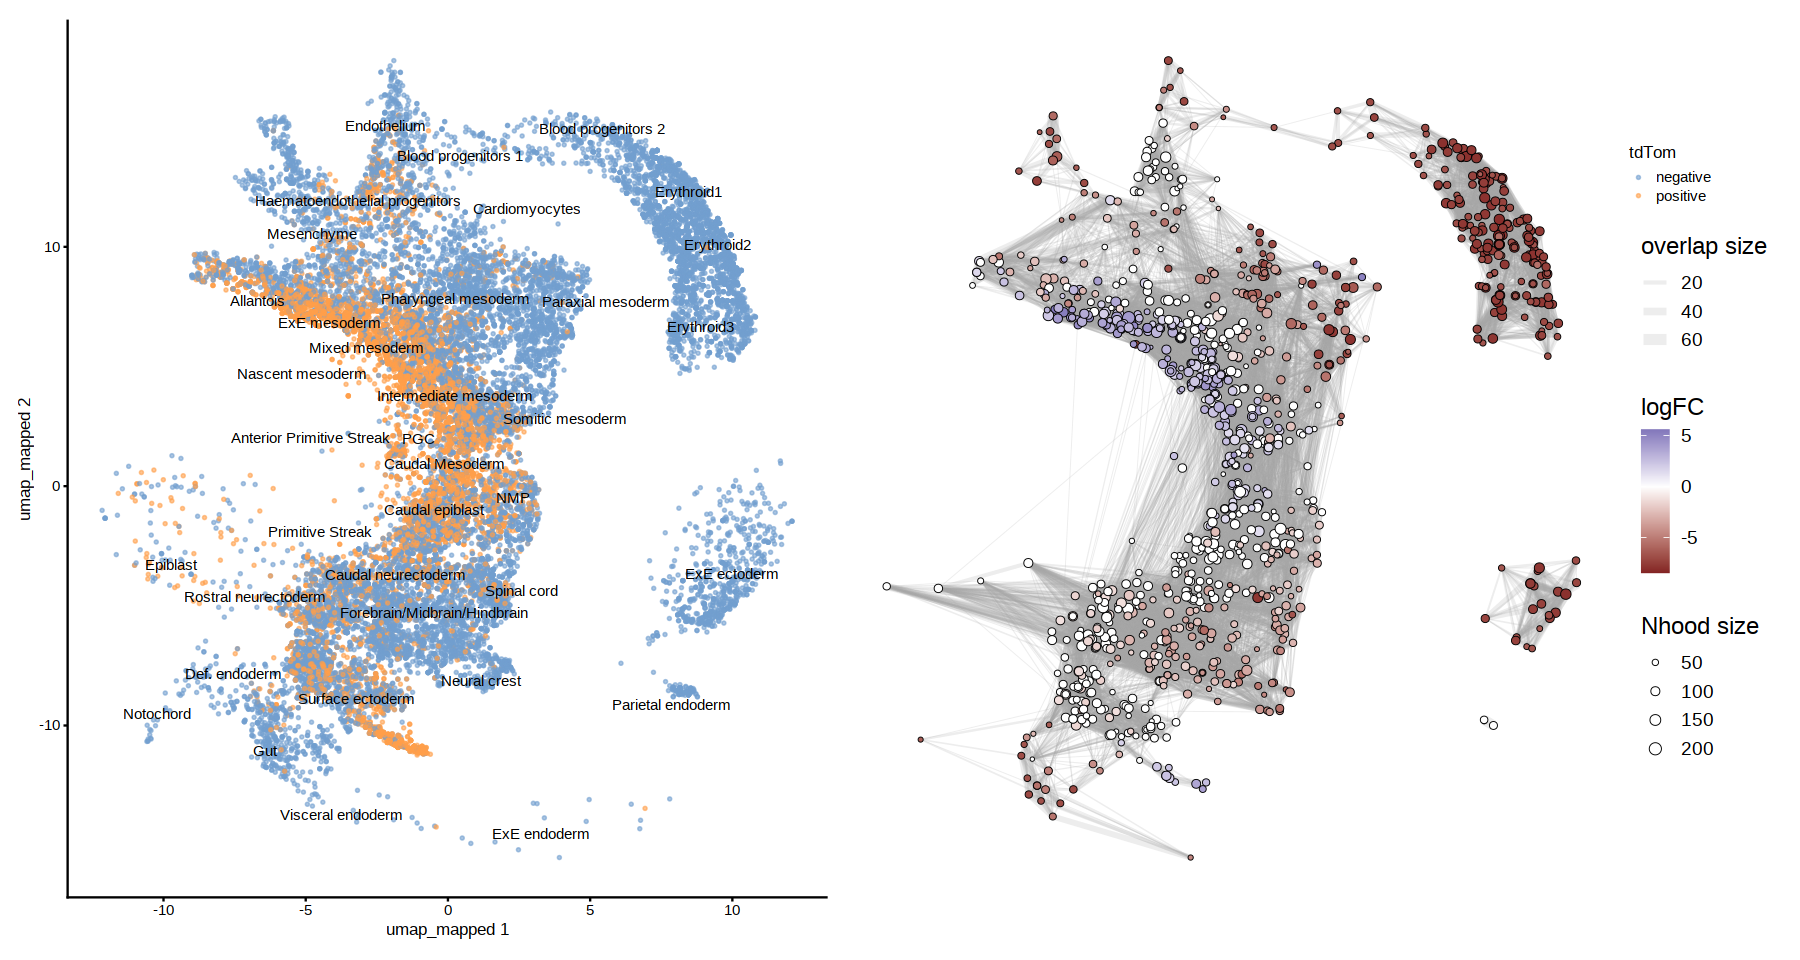

In [55]:
## Plot single-cell UMAP
umap_pl <- plotReducedDim(embryo_milo, dimred = "umap_mapped", colour_by="tdTom", text_by = "celltype.mapped", 
                          text_size = 3, point_size=0.5) +
  guides(fill="none")

## Plot neighbourhood graph
nh_graph_pl <- plotNhoodGraphDA(embryo_milo, da_results, layout="umap_mapped",alpha=0.1) 
  
umap_pl + nh_graph_pl +
  plot_layout(guides="collect")

In [56]:
embryo_milo

class: Milo 
dim: 22441 27776 
metadata(0):
assays(2): counts logcounts
rownames(22441): ENSMUSG00000051951 ENSMUSG00000089699 ...
  ENSMUSG00000095742 tomato-td
rowData names(0):
colnames(27776): cell_1 cell_2 ... cell_30169 cell_30171
colData names(22): barcode stage ... umapY.mapped sizeFactor
reducedDimNames(1): umap_mapped
mainExpName: NULL
altExpNames(0):
nhoods dimensions(2): 27776 1173
nhoodCounts dimensions(2): 1173 8
nhoodDistances dimension(1): 1173
graph names(1): graph
nhoodIndex names(1): 1173
nhoodExpression dimension(2): 1 1
nhoodReducedDim names(0):
nhoodGraph names(1): nhoodGraph
nhoodAdjacency dimension(2): 1173 1173

In [212]:
umap_mapped = colData(sce)[,c('umapX.mapped', 'umapY.mapped')]
reducedDims(sce) <- list(pca.corrected=pca, umap_mapped=umap_mapped)

In [213]:
embryo_data = Milo(sce)

In [214]:
reducedDim(embryo_data, "pca.corrected") = as.matrix(reducedDim(embryo_data, "pca.corrected"))

In [215]:
# embryo_data <- embryo_data[,apply(reducedDim(embryo_data, "pca.corrected"), 1, function(x) !all(is.na(x)))]
# embryo_data <- runUMAP(embryo_data, dimred = "pca.corrected", name = 'umap')

In [216]:
embryo_milo = Milo(embryo_data)

In [217]:
#embryo_milo = embryo_milo[,colData(embryo_milo)$Sample_name %in% c('MLT_G9 Tom+','MLT_G9 Tom-', 'MLT_C7-', 'MLT_C7+')] 
# works

In [218]:
embryo_milo

class: Milo 
dim: 29453 27776 
metadata(0):
assays(2): counts logcounts
rownames(29453): ENSMUSG00000051951 ENSMUSG00000089699 ...
  ENSMUSG00000095742 tomato-td
rowData names(0):
colnames(27776): cell_1 cell_2 ... cell_30169 cell_30171
colData names(21): barcode stage ... umapX.mapped umapY.mapped
reducedDimNames(2): pca.corrected umap_mapped
mainExpName: NULL
altExpNames(0):
nhoods dimensions(2): 1 1
nhoodCounts dimensions(2): 1 1
nhoodDistances dimension(1): 0
graph names(0):
nhoodIndex names(1): 0
nhoodExpression dimension(2): 1 1
nhoodReducedDim names(0):
nhoodGraph names(0):
nhoodAdjacency dimension(2): 1 1

In [219]:
embryo_milo <- buildGraph(embryo_milo, k = 30, d = 30, reduced.dim = "pca.corrected")

Constructing kNN graph with k:30



In [220]:
# lower prop for larger datasets
embryo_milo <- makeNhoods(embryo_milo, prop = 0.02, k = 30, d=30, refined = TRUE, reduced_dims = "pca.corrected")

Checking valid object



In [221]:
#embryo_milo = embryo_milo[,colData(embryo_milo)$Sample_name %in% c('MLT_G9 Tom+','MLT_G9 Tom-', 'MLT_C7-', 'MLT_C7+')]
# Don't work

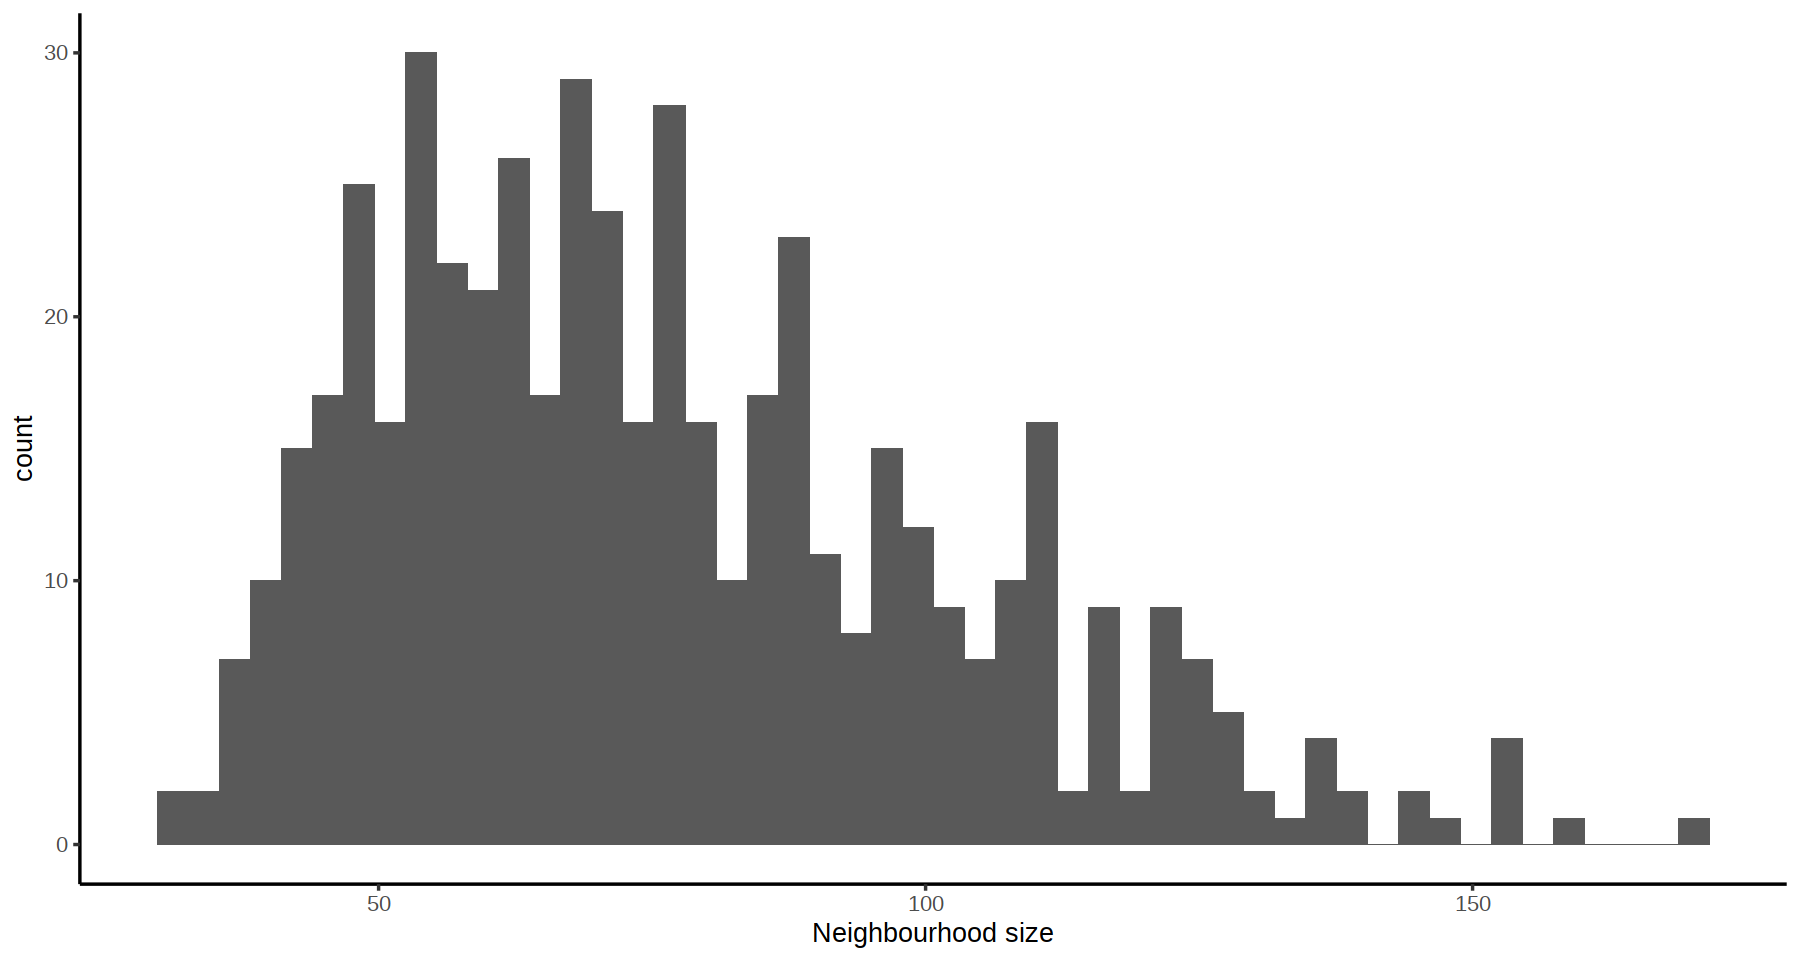

In [222]:
plotNhoodSizeHist(embryo_milo)

In [223]:
embryo_milo <- countCells(embryo_milo, meta.data = as.data.frame(colData(embryo_milo)), sample="sample")

Checking meta.data validity

Counting cells in neighbourhoods



In [224]:
embryo_milo

class: Milo 
dim: 29453 27776 
metadata(0):
assays(2): counts logcounts
rownames(29453): ENSMUSG00000051951 ENSMUSG00000089699 ...
  ENSMUSG00000095742 tomato-td
rowData names(0):
colnames(27776): cell_1 cell_2 ... cell_30169 cell_30171
colData names(21): barcode stage ... umapX.mapped umapY.mapped
reducedDimNames(2): pca.corrected umap_mapped
mainExpName: NULL
altExpNames(0):
nhoods dimensions(2): 27776 513
nhoodCounts dimensions(2): 513 8
nhoodDistances dimension(1): 0
graph names(1): graph
nhoodIndex names(1): 513
nhoodExpression dimension(2): 1 1
nhoodReducedDim names(0):
nhoodGraph names(0):
nhoodAdjacency dimension(2): 1 1

In [225]:
head(nhoodCounts(embryo_milo))

6 x 8 sparse Matrix of class "dgCMatrix"
  3  8  4  5  1  6  2 7
1 6  3  4 12 22  2 13 7
2 . 20 32  .  . 27 29 .
3 2  2  3 28 17  5 28 4
4 .  . 42  .  . 21  2 .
5 .  9 15 21 25  9 16 1
6 . 11 13  .  .  7 28 .

In [208]:
colnames(colData(embryo_milo))

[1] "barcode"         "stage"           "batch"           "Sample_name"    
 [5] "batch_name"      "tdTom"           "index"           "sample"         
 [9] "doub.density"    "doublet"         "stripped"        "umap_1"         
[13] "umap_2"          "louvain_cluster" "celltype.mapped" "stage.mapped"   
[17] "closest.cell"    "celltype.score"  "cellstage.score" "umapX.mapped"   
[21] "umapY.mapped"

In [242]:
colData(embryo_milo)[colData(embryo_milo)$Sample_name=='MLT_C7+',]$tdTom = 'positive'

In [243]:
embryo_design <- data.frame(colData(embryo_milo))[,c("sample", "tdTom")]

## Convert batch info from integer to factor

embryo_design <- distinct(embryo_design)
#rownames(embryo_design) <- embryo_design$sample
rownames(embryo_design) <- 1:nrow(embryo_design)

embryo_design

,sample,tdTom
,<int>,<chr>
1,3,positive
2,8,negative
3,4,negative
4,5,positive
5,1,positive
6,6,negative
7,2,negative
8,7,positive


In [230]:
embryo_milo <- calcNhoodDistance(embryo_milo, d=30, reduced.dim = "pca.corrected")

In [244]:
# design = what to test for, can correct for another variable as well
da_results <- testNhoods(embryo_milo, design = ~ tdTom, design.df = embryo_design, reduced.dim="pca.corrected")
head(da_results)

Warning message in testNhoods(embryo_milo, design = ~tdTom, design.df = embryo_design, :
“Sample names in design matrix and nhood counts are not matched. Reordering”
Using TMM normalisation

Performing spatial FDR correction withk-distance weighting



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-0.582758148,11.21500,0.497482556,0.4972357,0.9981665,1,0.9981264
2,-0.008996655,11.82173,0.000023682,0.9962208,0.9981665,2,0.9981264
3,-0.394777576,11.29451,0.202182647,0.6628690,0.9981665,3,0.9981264
4,0.366883708,11.11142,0.033000925,0.8597773,0.9981665,4,0.9981264
5,0.960183455,11.38109,1.005923577,0.3404669,0.9981665,5,0.9981264
6,-0.292054085,11.03453,0.028425951,0.8697501,0.9981665,6,0.9981264


In [ ]:
da_results %>%
  arrange(SpatialFDR) %>%
  head() 

In [ ]:
ggplot(da_results, aes(PValue)) + geom_histogram(bins=50)

In [ ]:
ggplot(da_results, aes(logFC, -log10(SpatialFDR))) + 
  geom_point() +
  geom_hline(yintercept = 1) ## Mark significance threshold (10% FDR)

In [ ]:
options(repr.plot.width=15, repr.plot.height=8)

In [ ]:
embryo_milo <- buildNhoodGraph(embryo_milo)

## Plot single-cell UMAP
umap_pl <- plotReducedDim(embryo_milo, dimred = "umap_mapped", colour_by="tdTom", text_by = "celltype.mapped", 
                          text_size = 3, point_size=0.5) +
  guides(fill="none")

## Plot neighbourhood graph
nh_graph_pl <- plotNhoodGraphDA(embryo_milo, da_results, layout="umap_mapped",alpha=0.1) 
  
umap_pl + nh_graph_pl +
  plot_layout(guides="collect")

In [62]:
test = testDiffExp(embryo_milo, da_results, design = ~ tdTom, meta.data = as.data.frame(colData(embryo_milo)))

Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”


Coefficients not estimable: tdTompositive 


Warning message:
“Partial NA coefficients for 22441 probe(s)”
Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message in out$var.prior[is.na(out$var.prior)] <- 1/out$s2.prior:
“number of items to replace is not a multiple of replacement length”
Warning message in .ebayes(fit = fit, proportion = proportion, stdev.coef.lim = stdev.coef.lim, :
“Estimation of var.prior failed - set to default value”
Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”


Coefficients not estimable: tdTompositive 


Warning message:
“Partial NA coefficients for 22441 probe(s)”
Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message in out$var.prior[is.na(out$var.prior)] <- 1/out$s2.prior:
“number of items to replace is not a multiple of replacement length”
Warning message in .ebayes(fit = fit, proportion = proportion, stdev.coef.lim = stdev.coef.lim, :
“Estimation of var.prior failed - set to default value”
Warning message:
“Zero sample variances detected, have been offset away from zero”


Coefficients not estimable: tdTompositive 


Warning message:
“Partial NA coefficients for 22441 probe(s)”
Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message in out$var.prior[is.na(out$var.prior)] <- 1/out$s2.prior:
“number of items to replace is not a multiple of replacement length”
Warning message in .ebayes(fit = fit, proportion = proportion, stdev.coef.lim = stdev.coef.lim, :
“Estimation of var.prior failed - set to default value”
Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”


Coefficients not estimable: tdTompositive 


Warning message:
“Partial NA coefficients for 22441 probe(s)”
Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message in out$var.prior[is.na(out$var.prior)] <- 1/out$s2.prior:
“number of items to replace is not a multiple of replacement length”
Warning message in .ebayes(fit = fit, proportion = proportion, stdev.coef.lim = stdev.coef.lim, :
“Estimation of var.prior failed - set to default value”


In [71]:
names(test)

[1] "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10" "11" "12" "13" "14" "15"
[16] "16" "17" "18" "19"

In [72]:
head(test[[9]])

,logFC,AveExpr,t,P.Value,adj.P.Val,B,Nhood.Group
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUSG00000052217,-1.8717366,1.317161,-49.78977,0,0,869.3981,9
ENSMUSG00000020176,-1.9668757,1.585464,-48.66977,0,0,840.3662,9
ENSMUSG00000020460,0.6306995,6.293140,57.11211,0,0,1059.2458,9
ENSMUSG00000055609,-2.2129928,1.571641,-58.61609,0,0,1098.0552,9
ENSMUSG00000057113,0.5516927,6.785616,48.08480,0,0,825.2189,9
ENSMUSG00000060938,0.8431611,5.531511,61.07667,0,0,1161.2804,9


In [86]:
length(test)

[1] 19

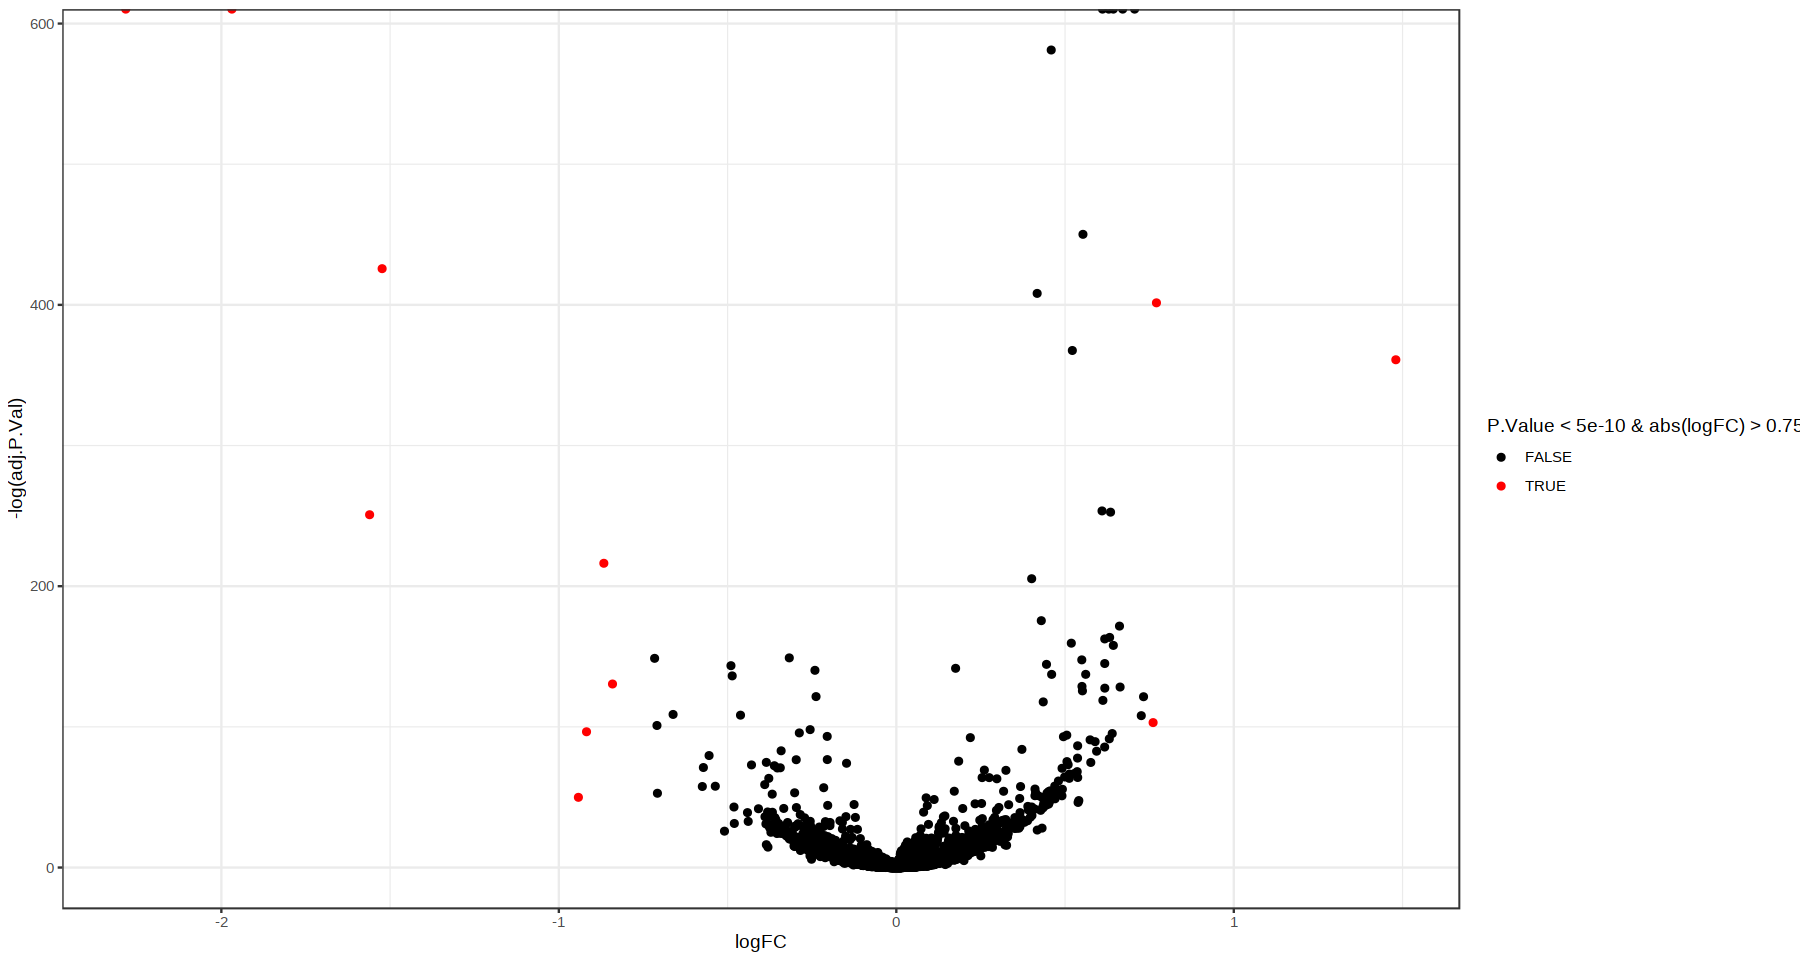

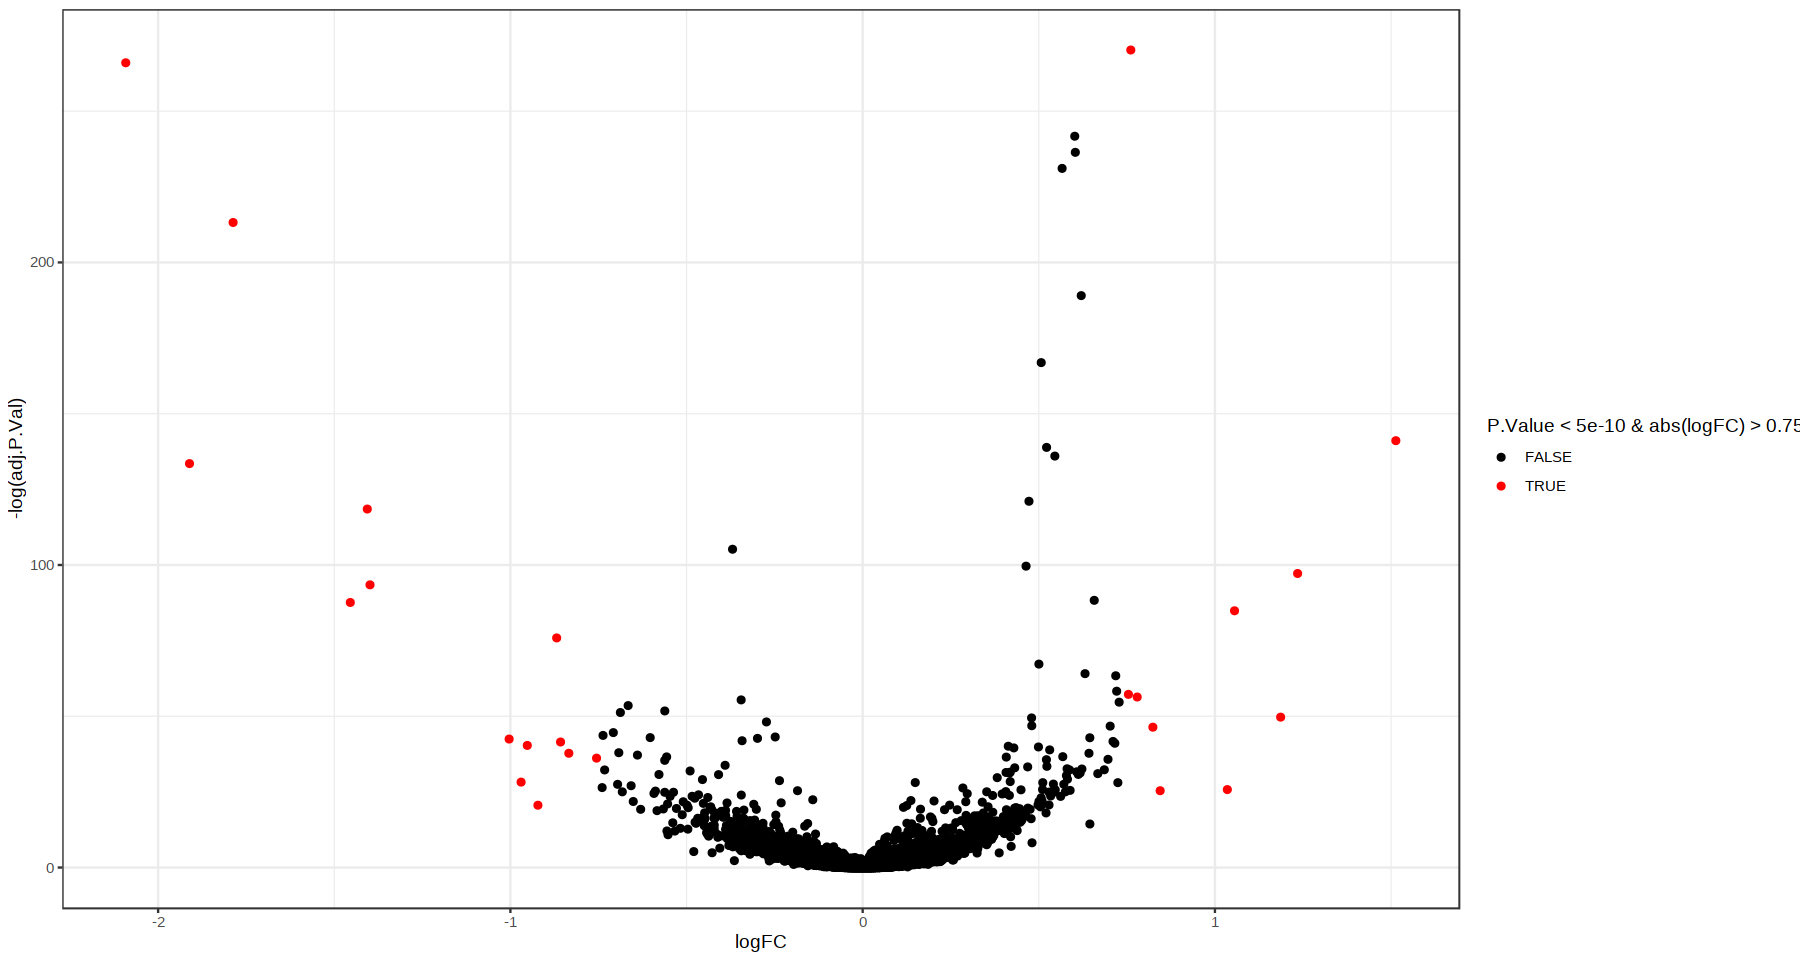

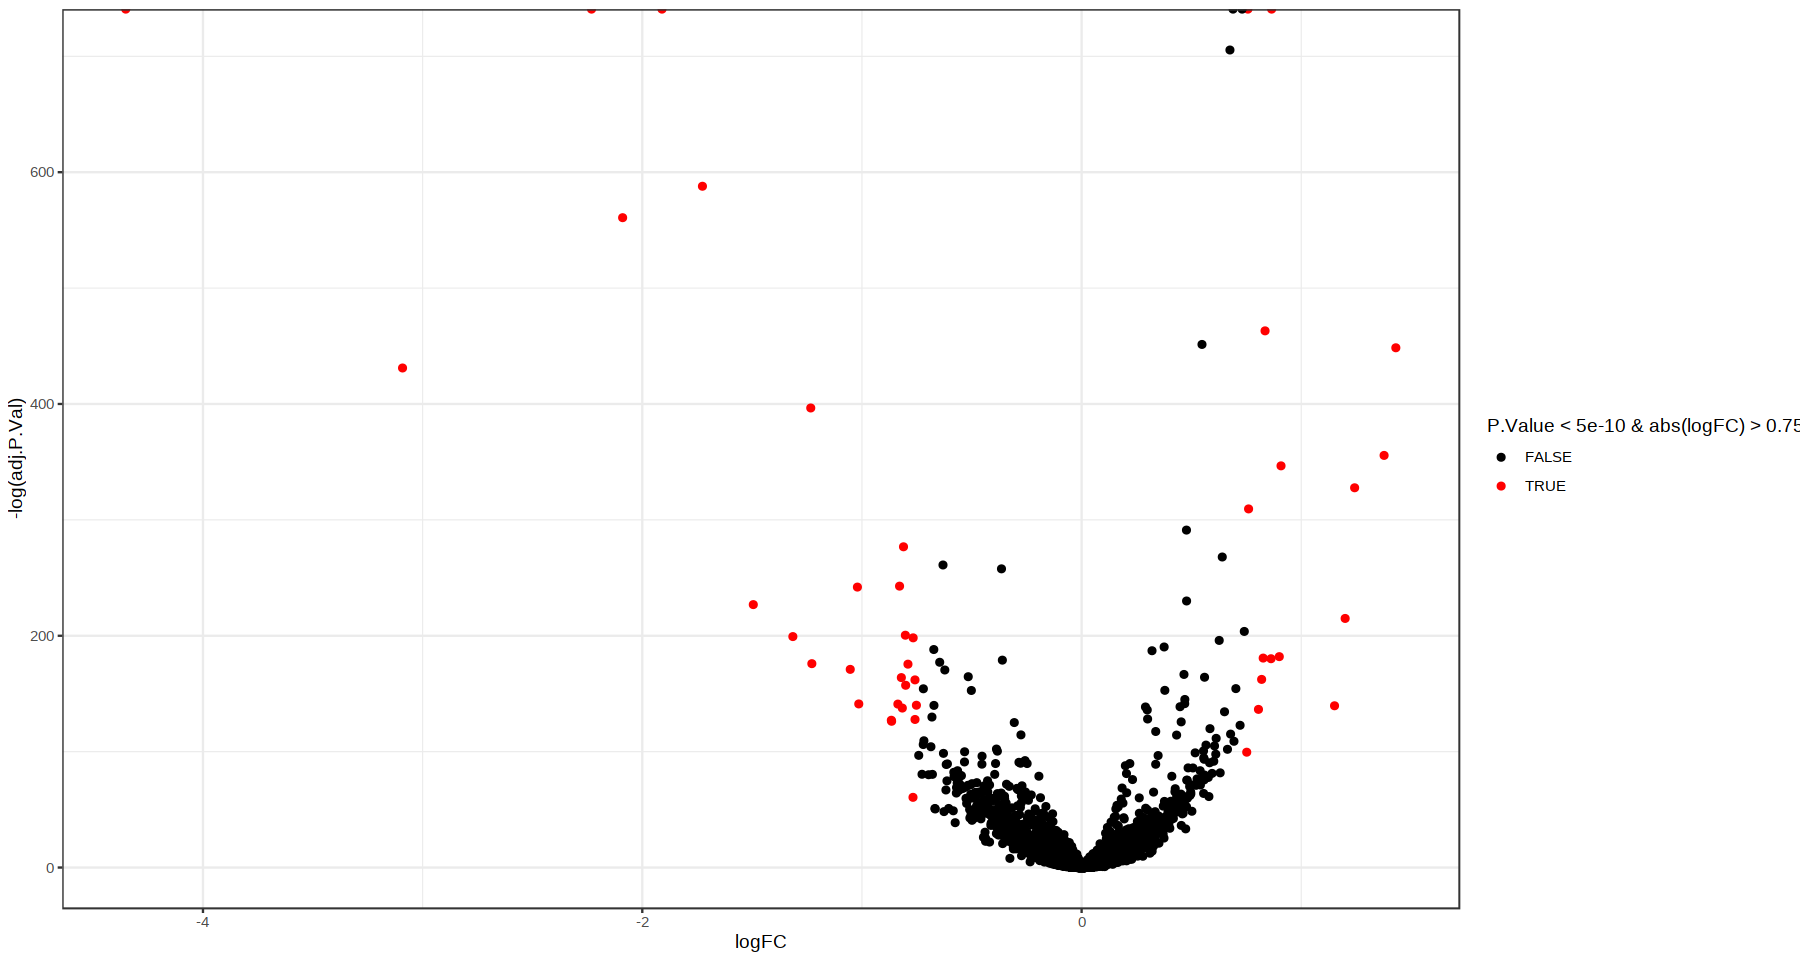

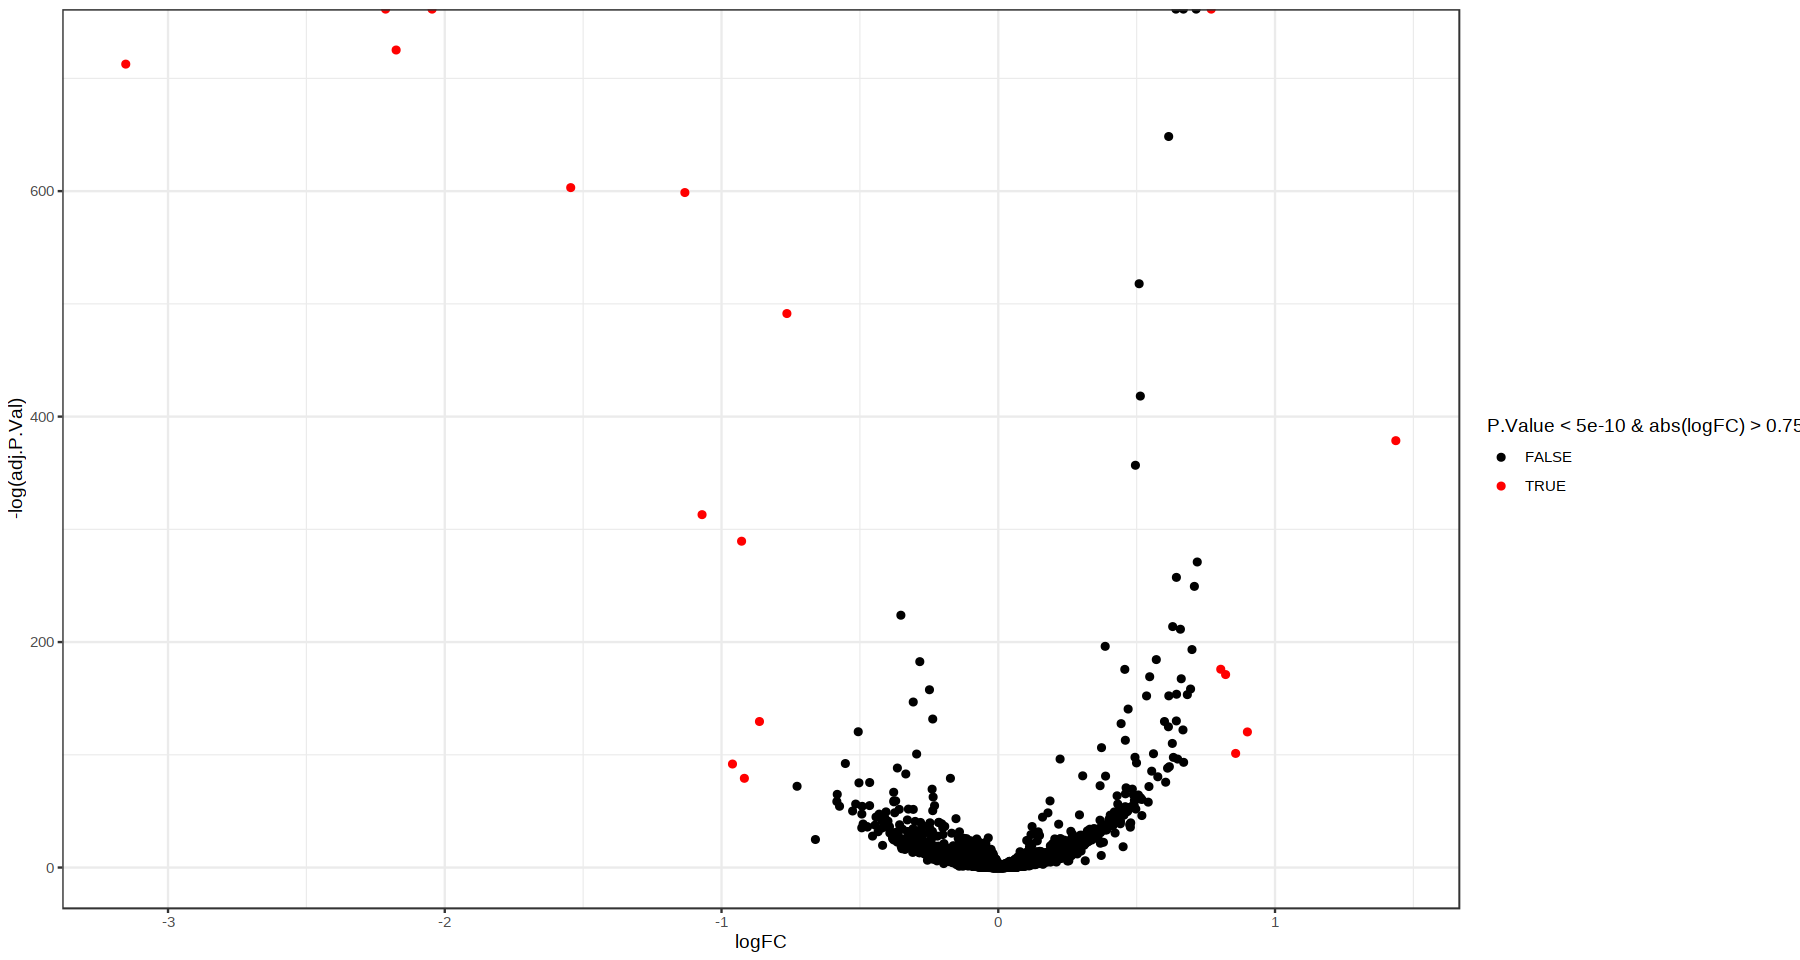

Warning message:
“Removed 22441 rows containing missing values (geom_point).”


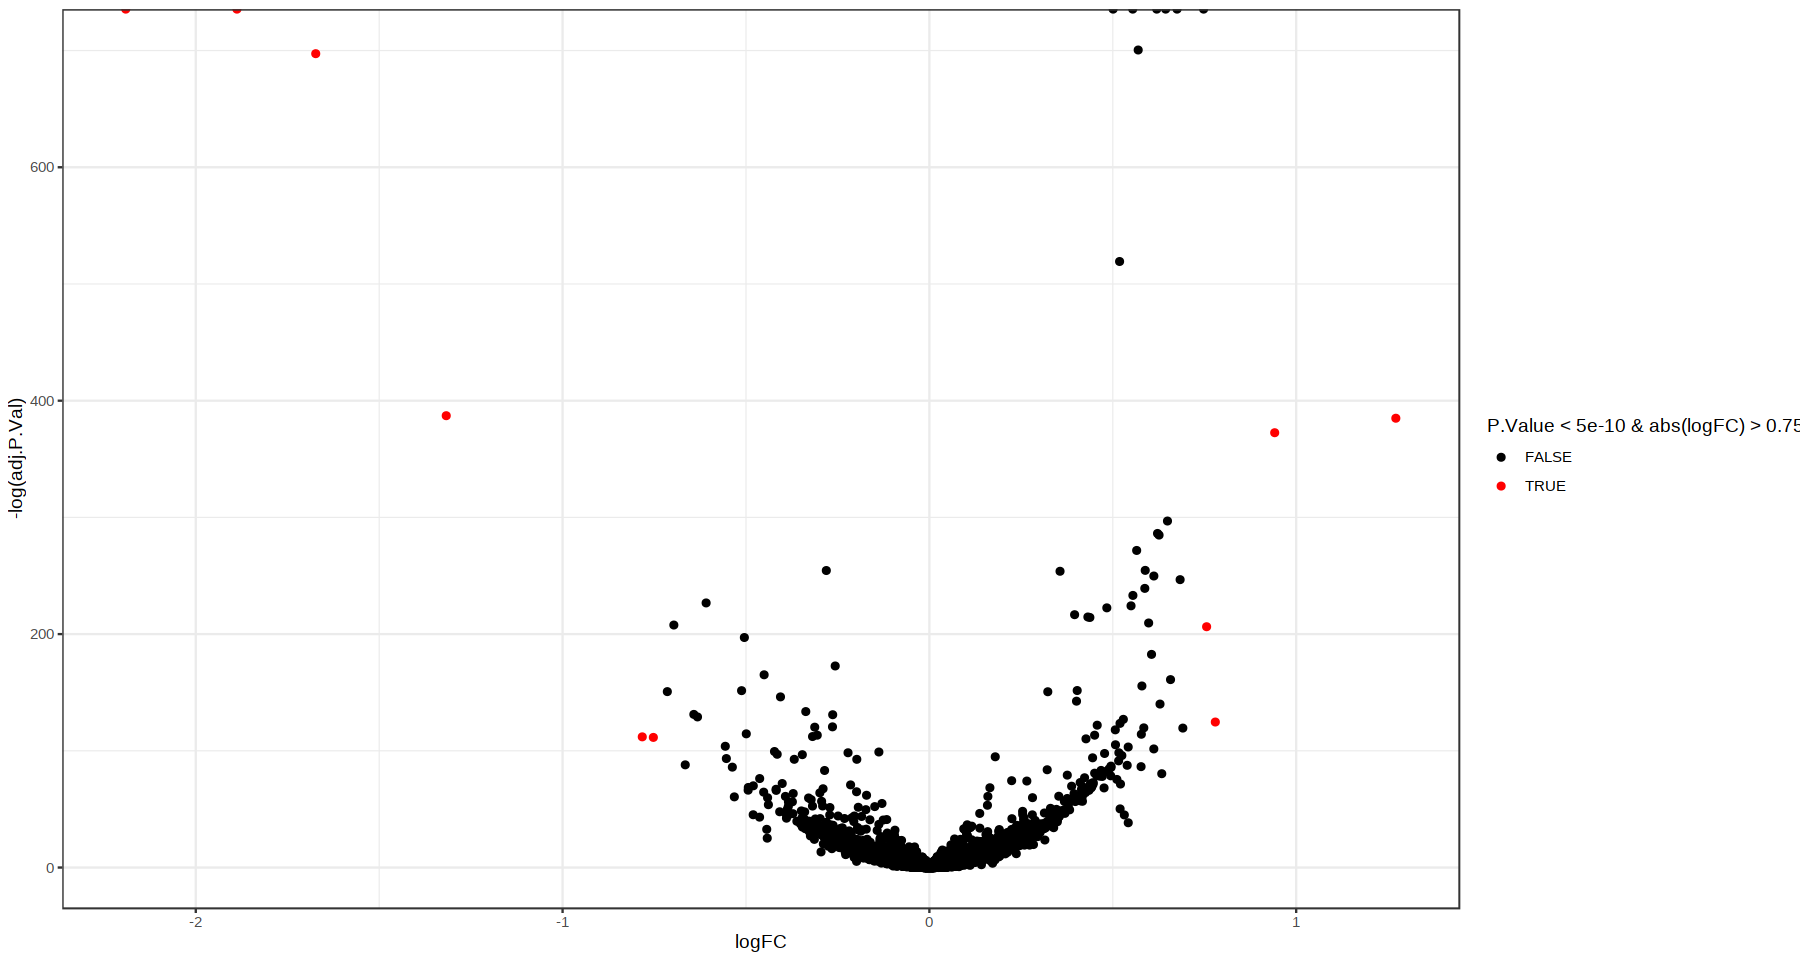

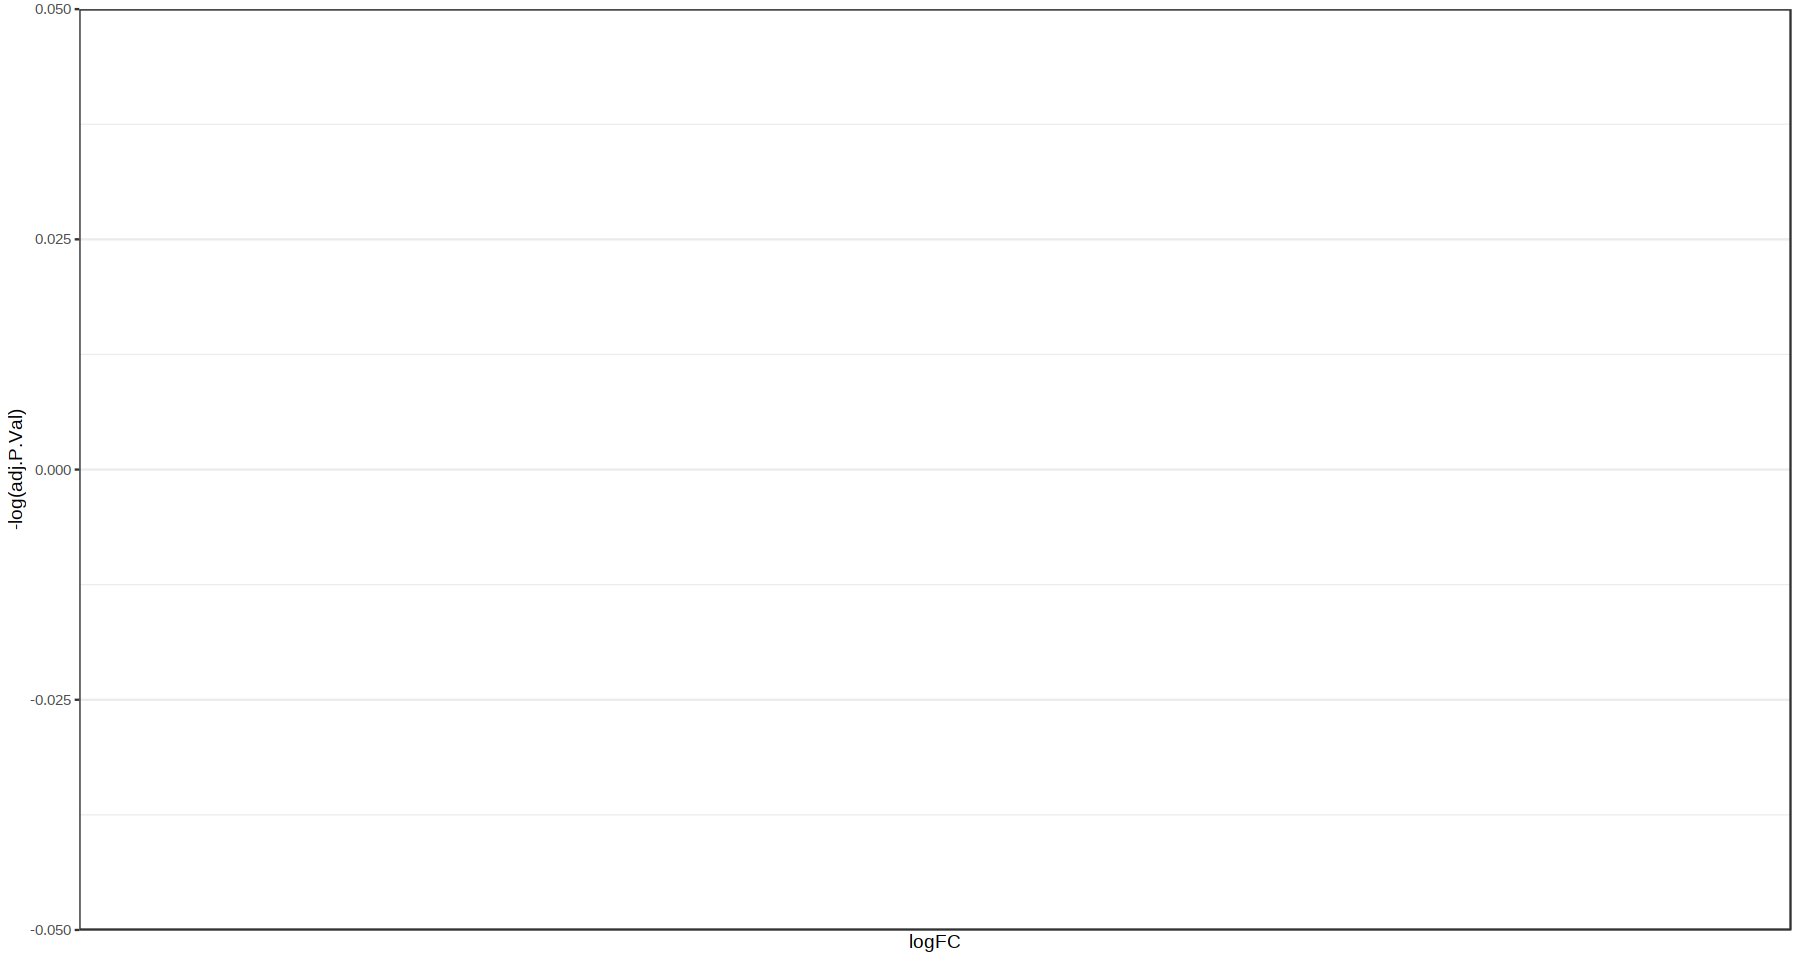

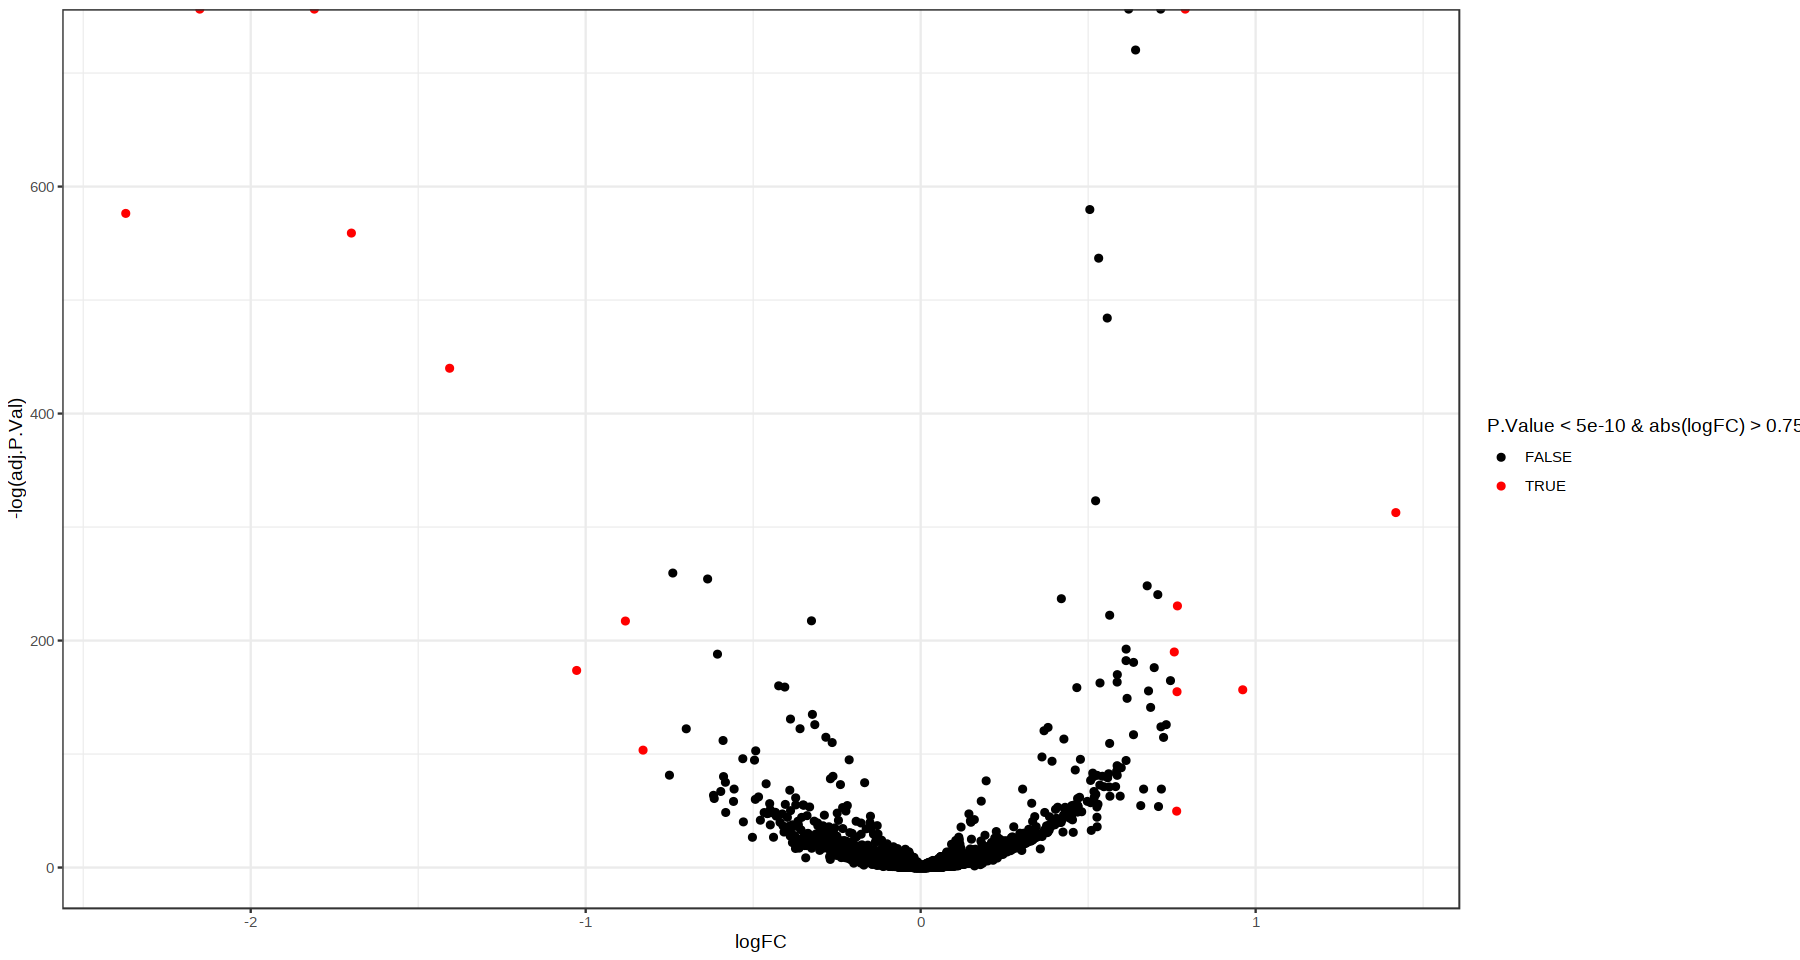

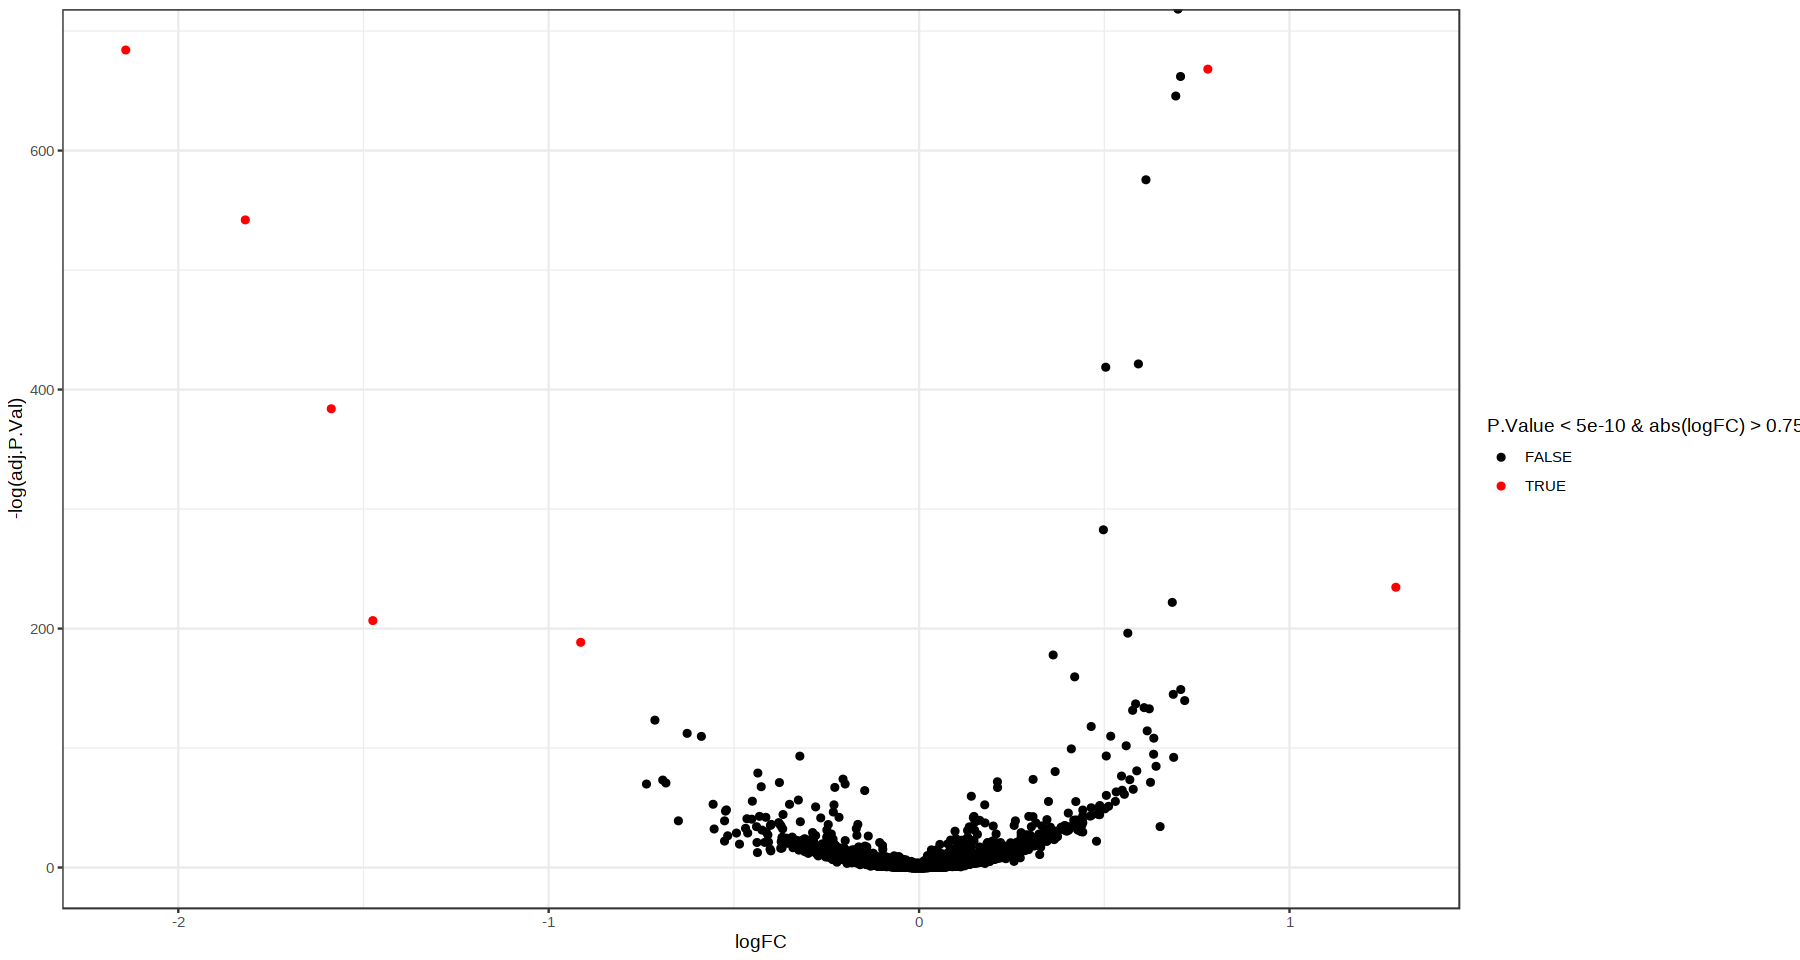

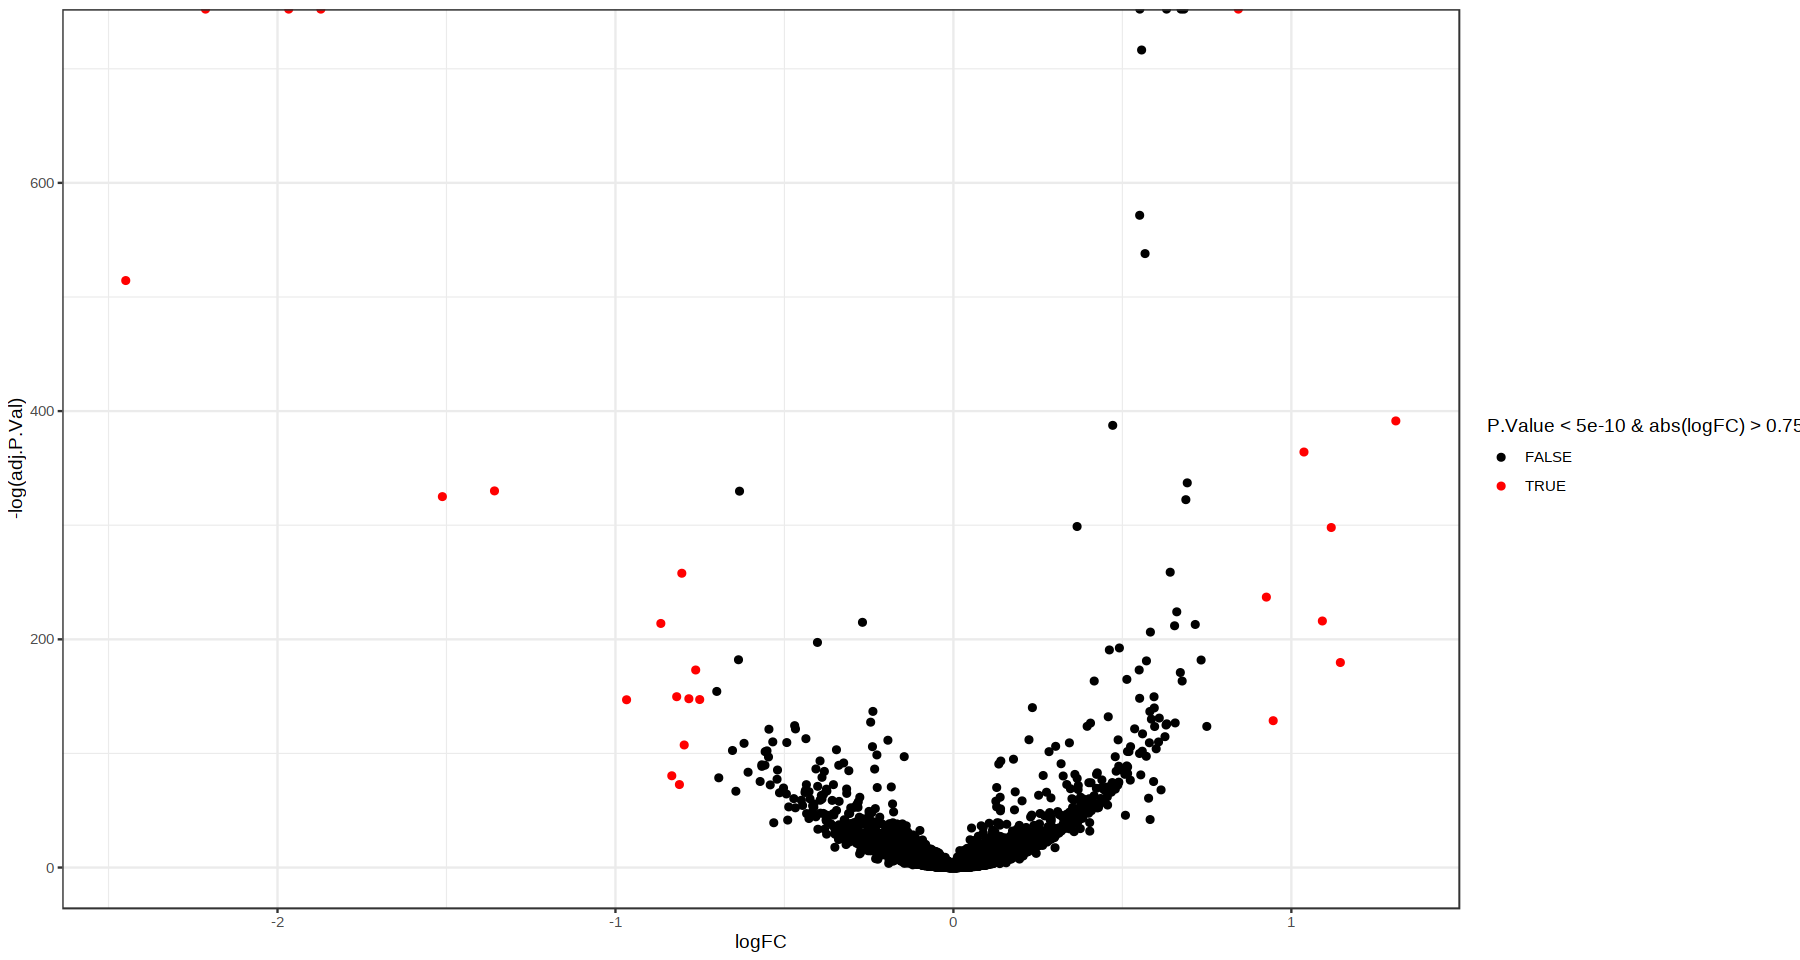

Warning message:
“Removed 22441 rows containing missing values (geom_point).”


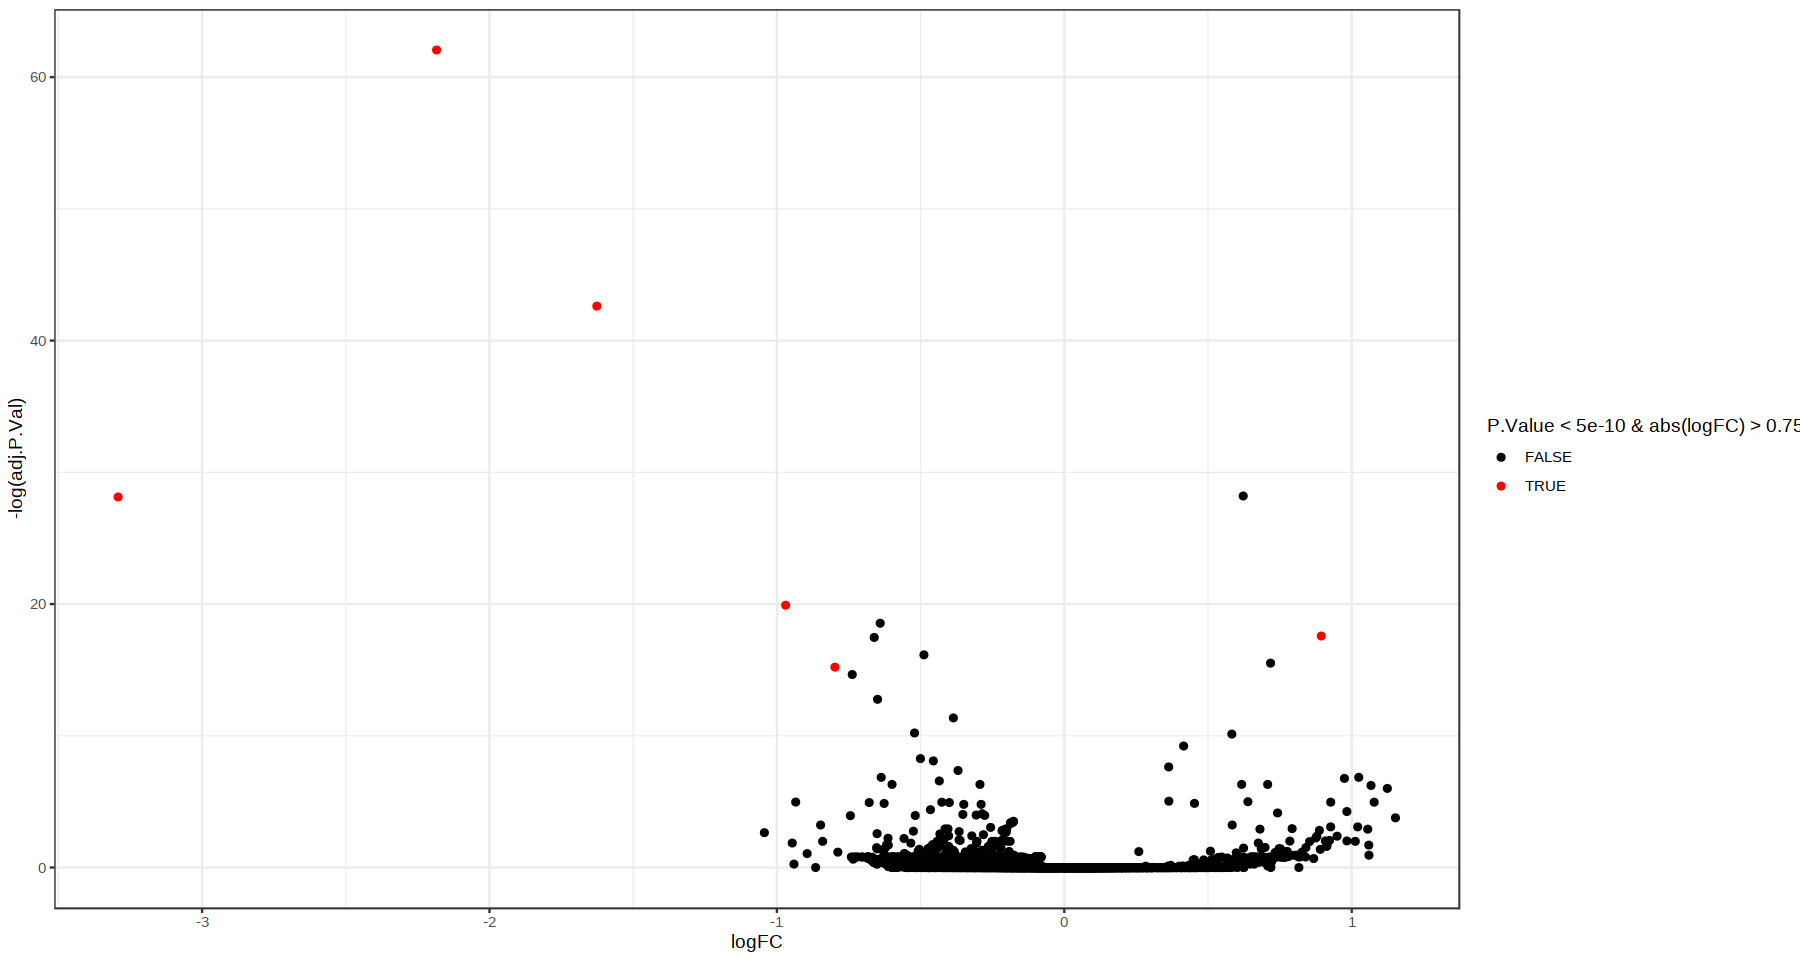

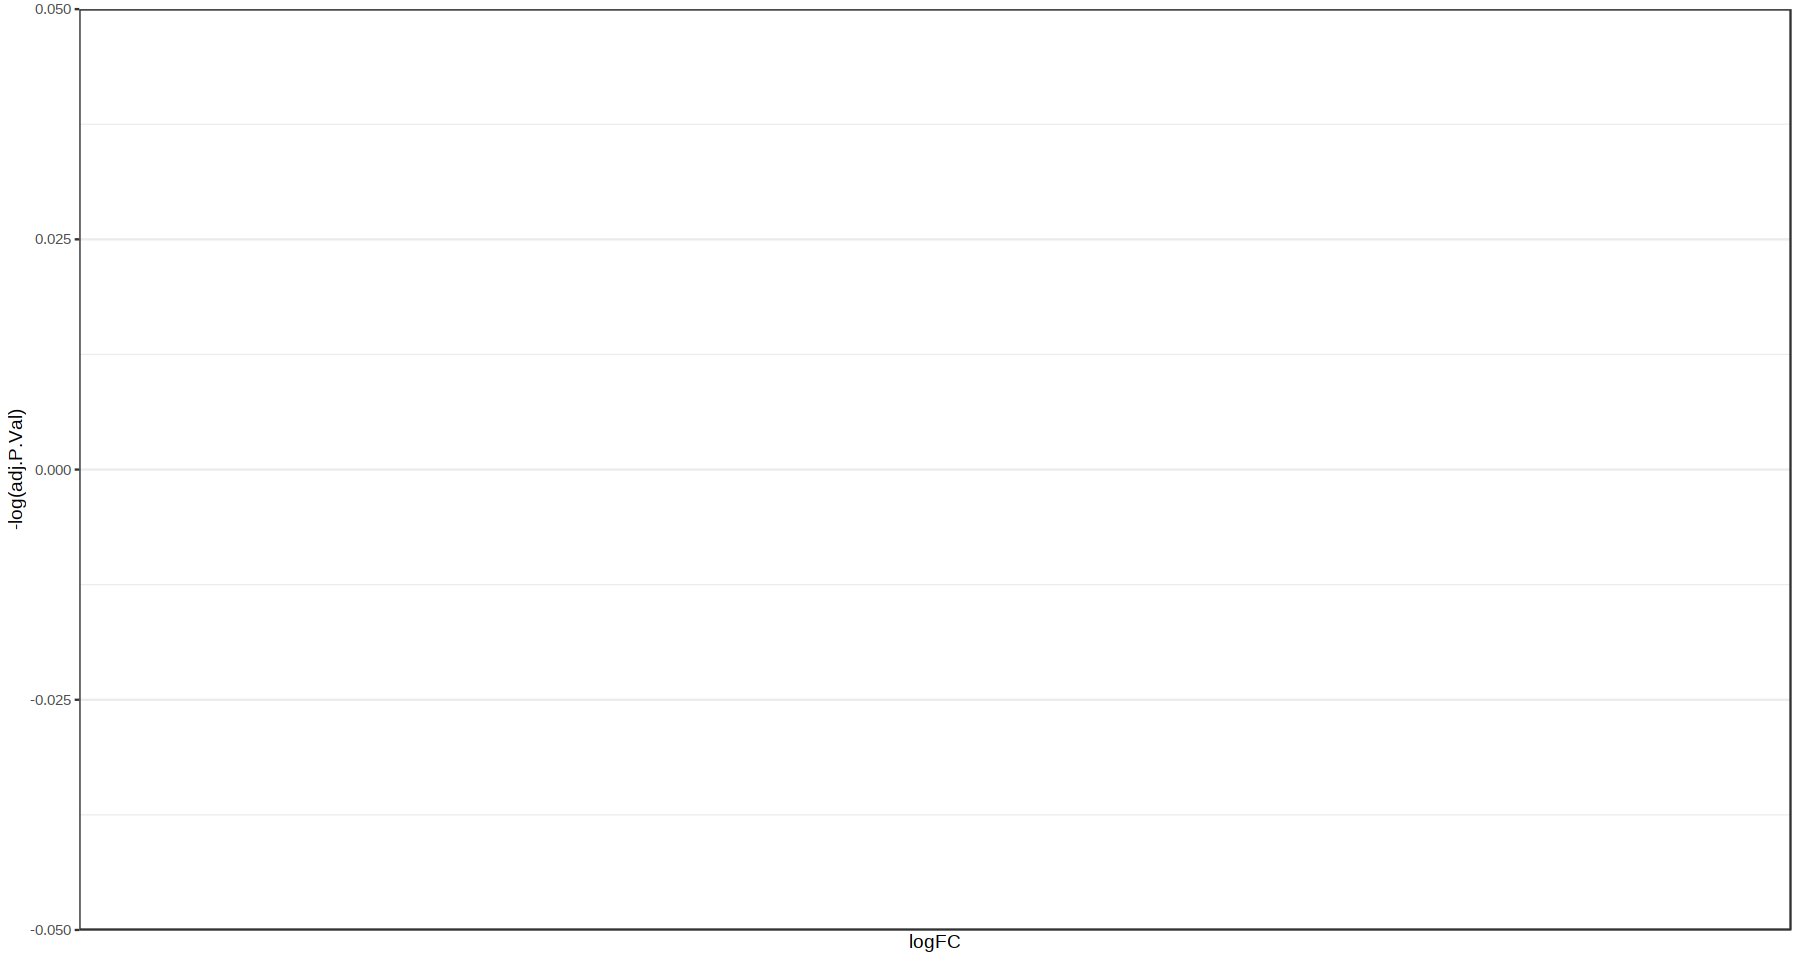

Warning message:
“Removed 22441 rows containing missing values (geom_point).”


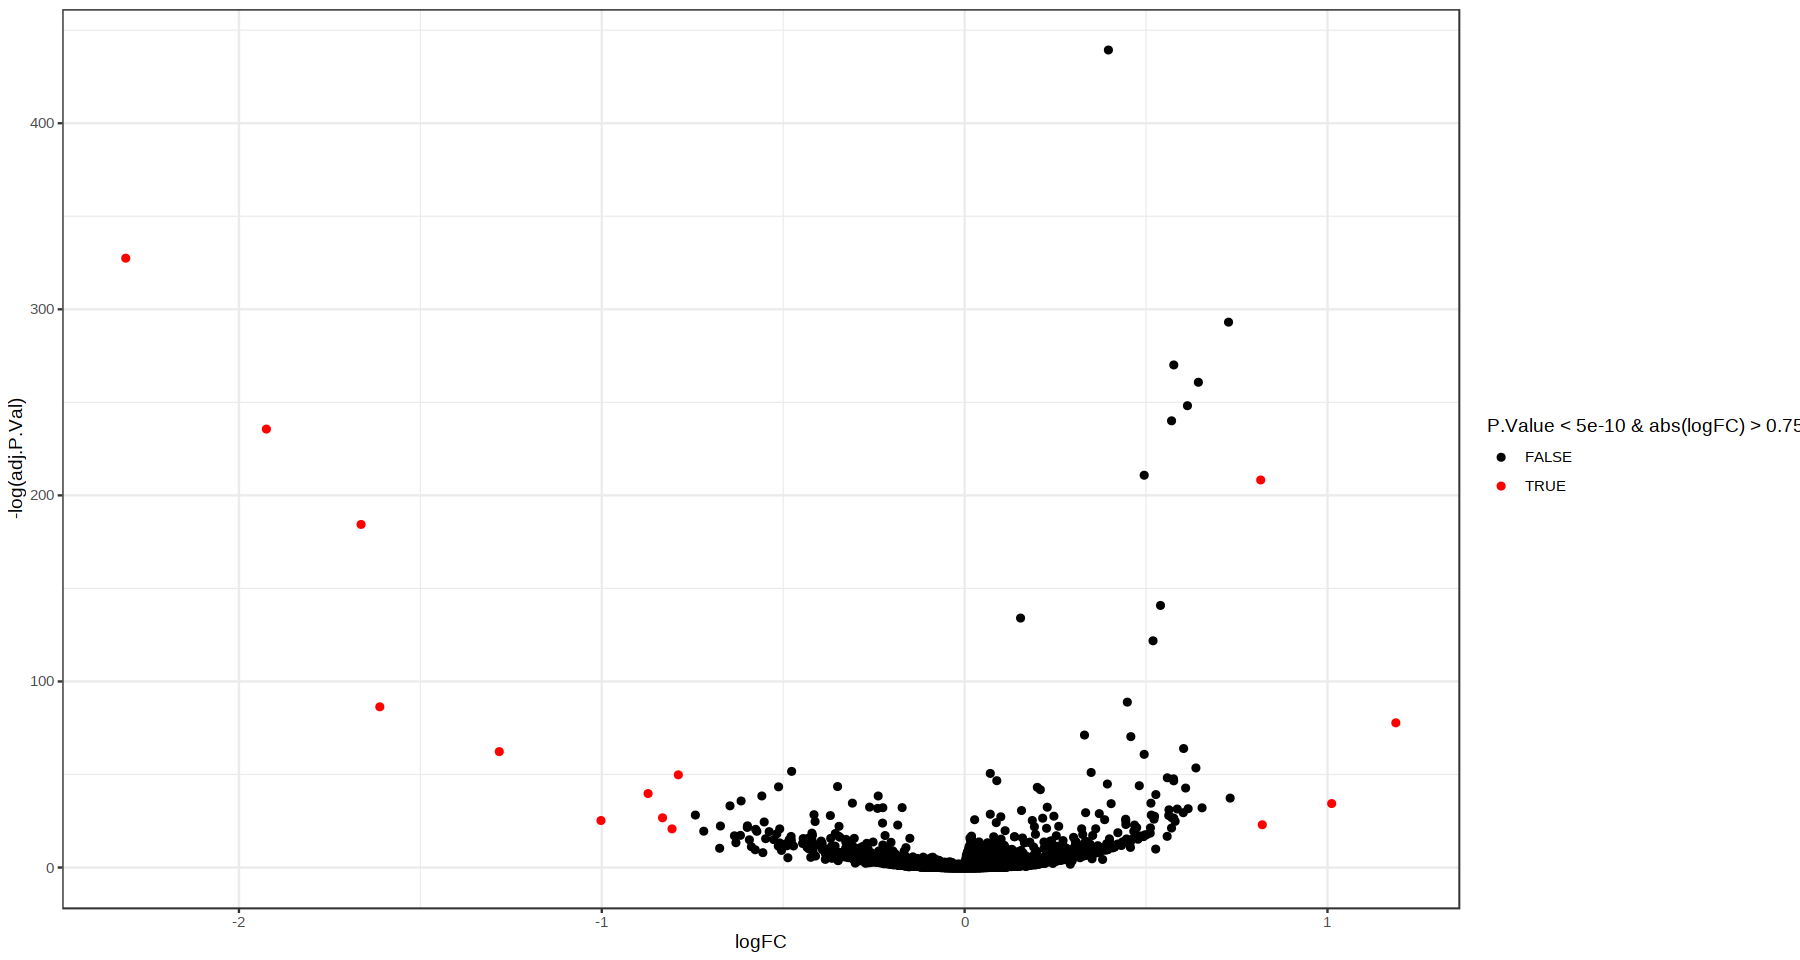

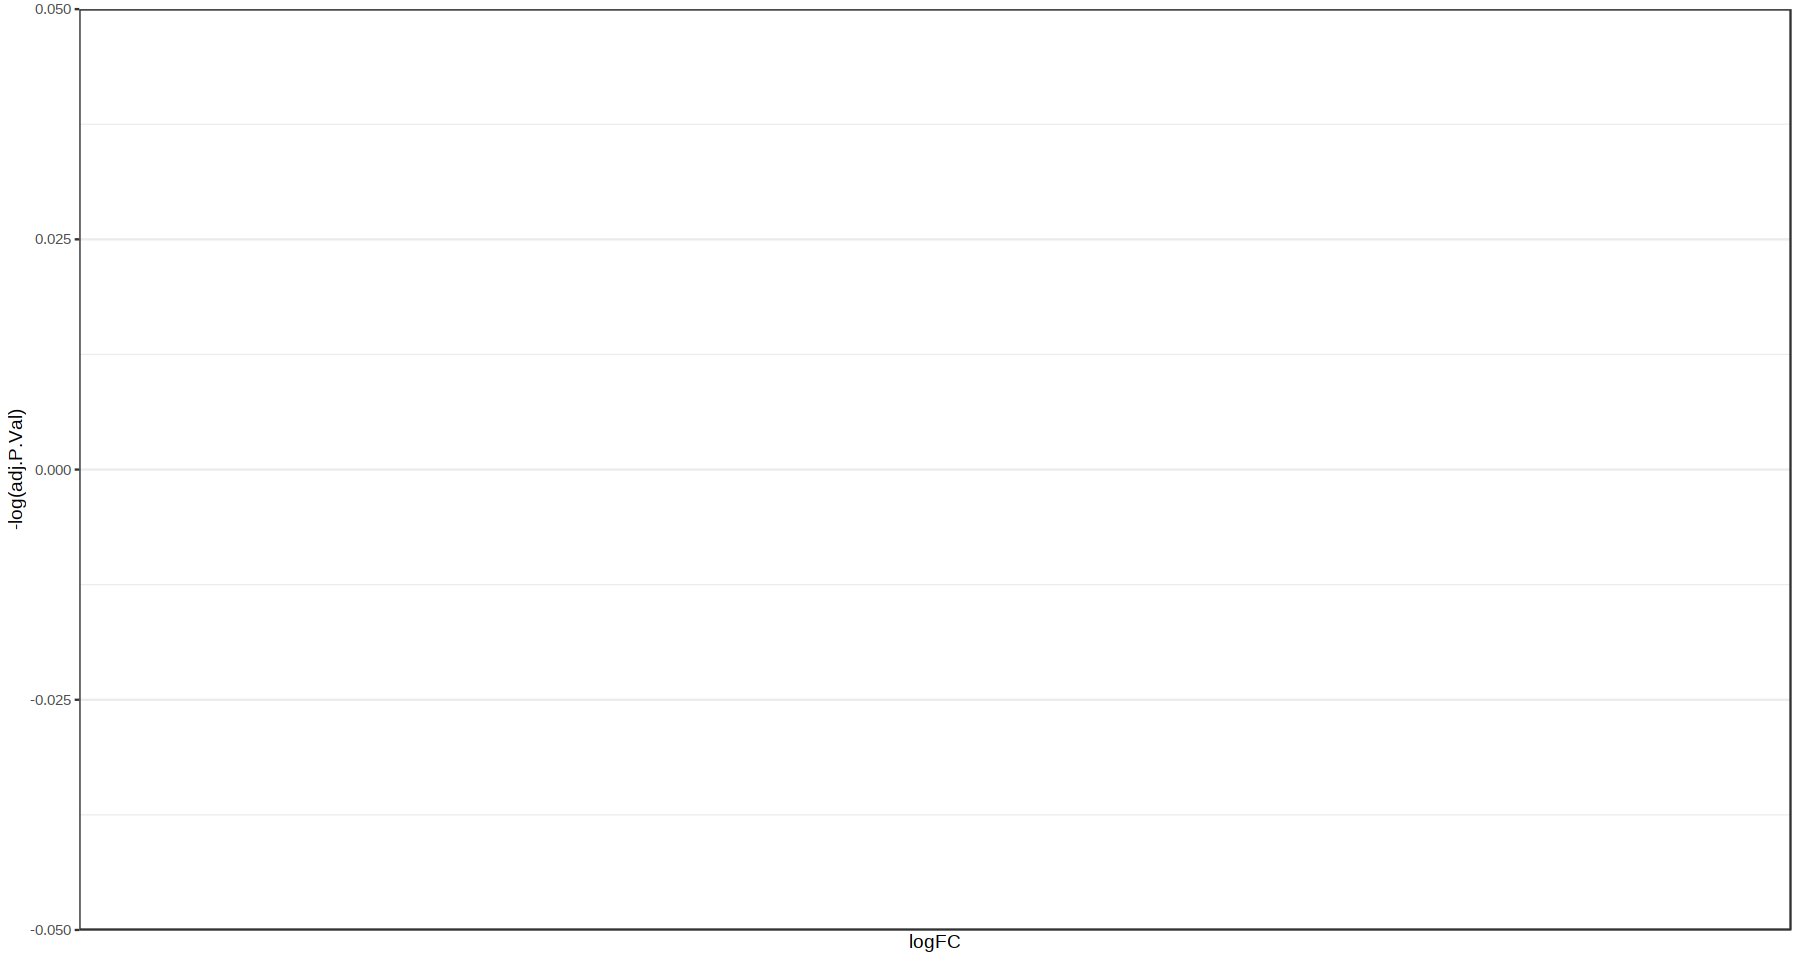

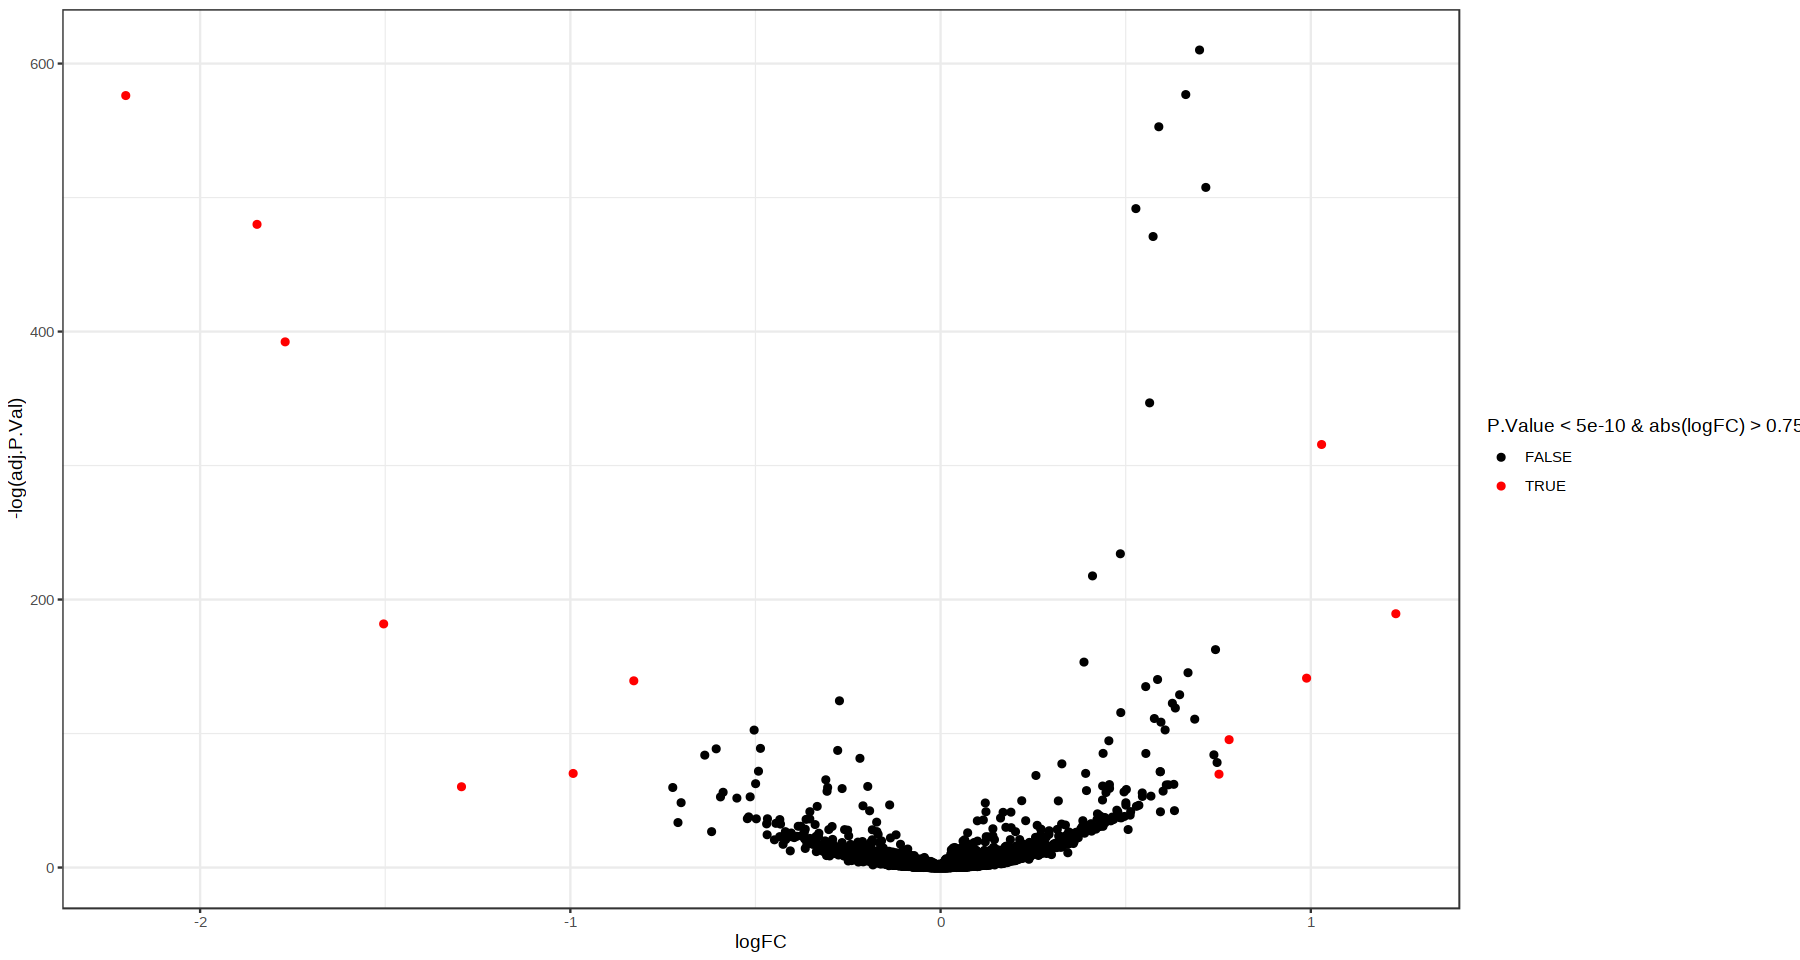

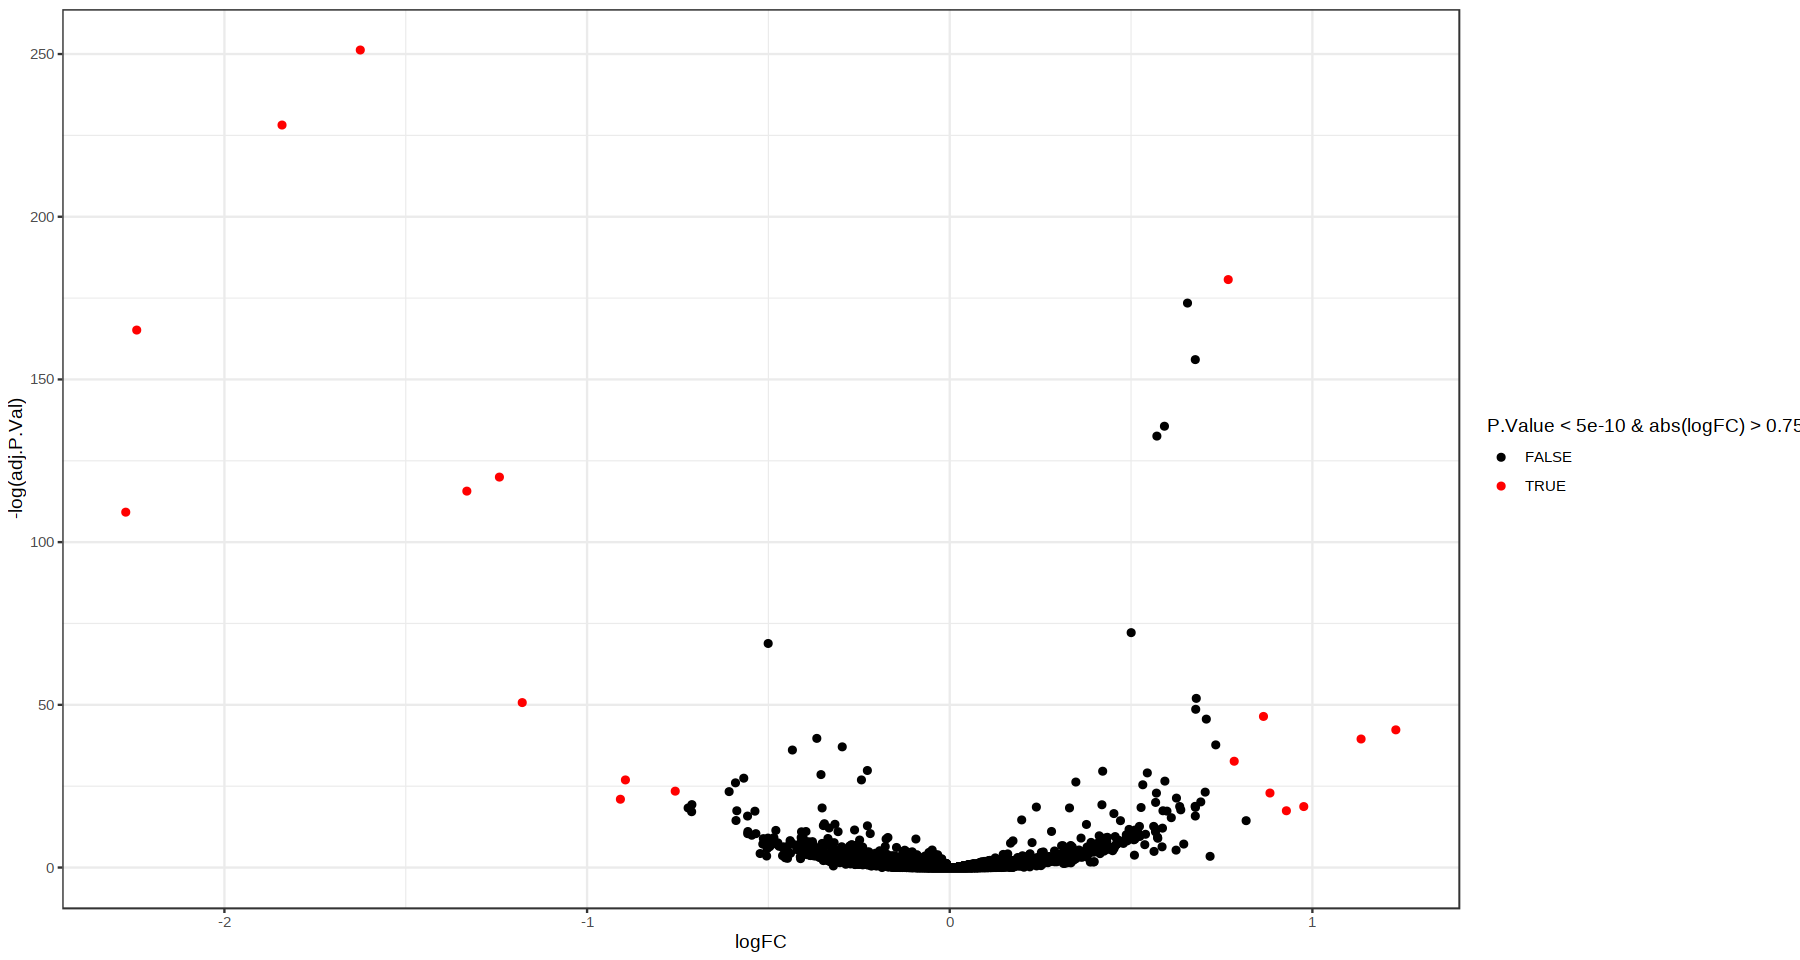

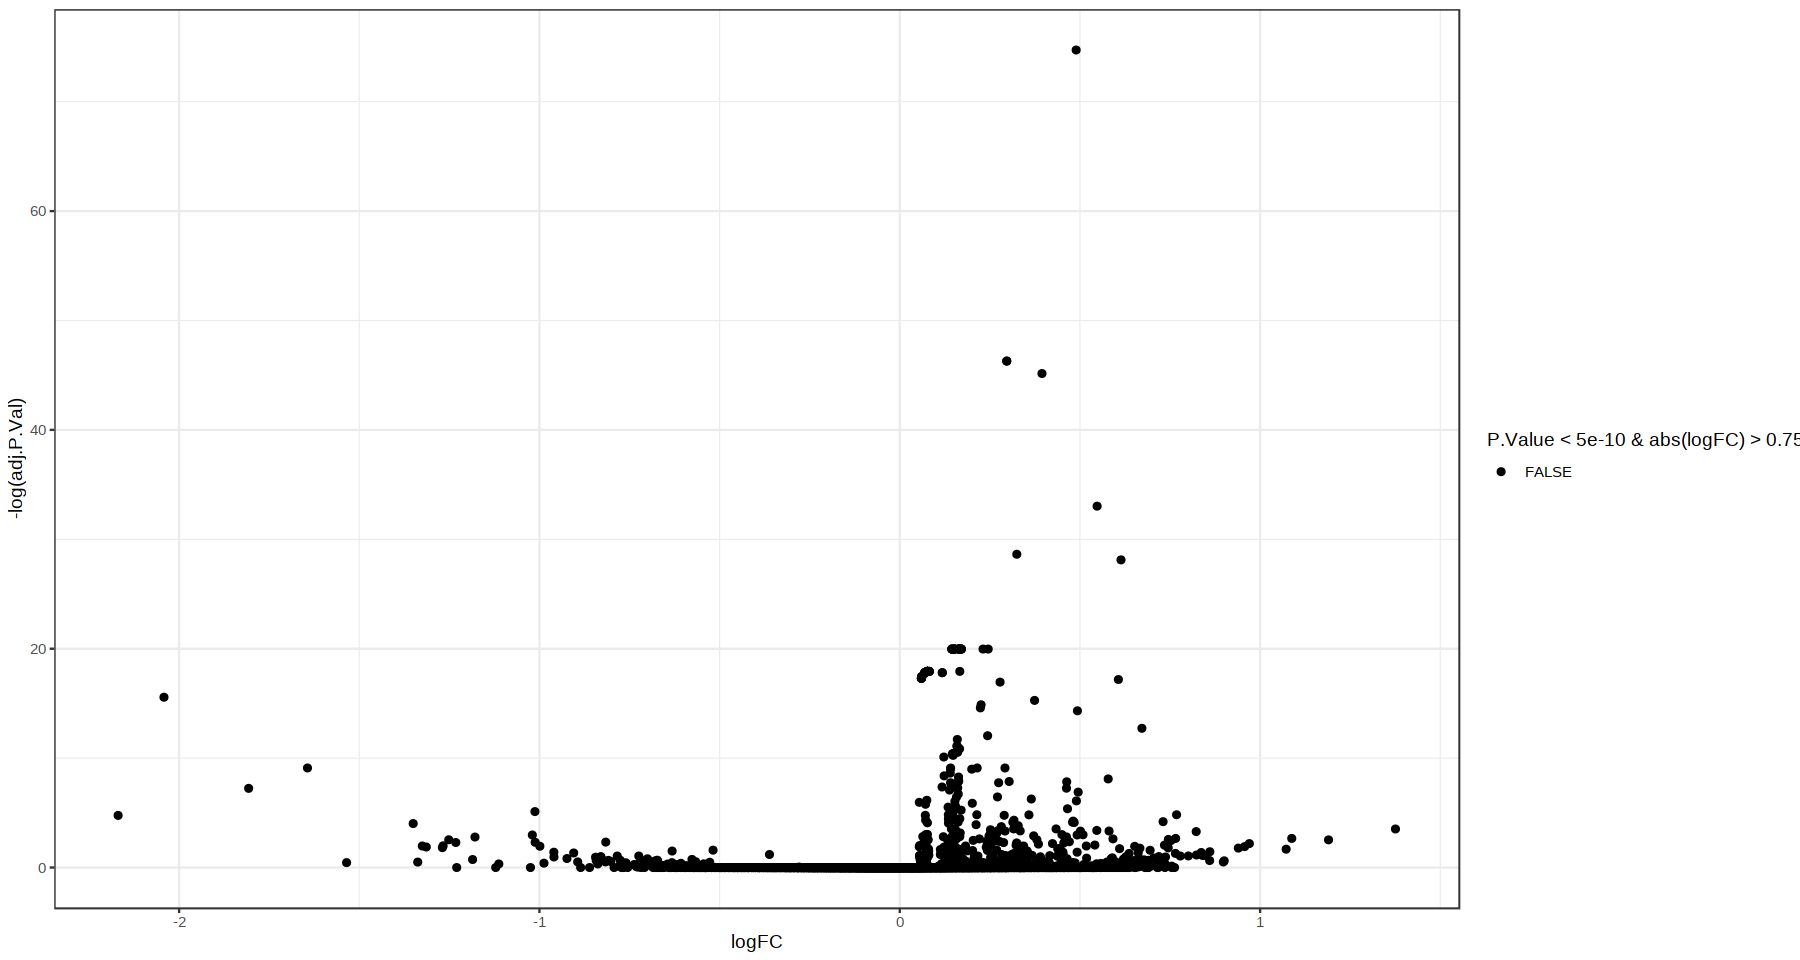

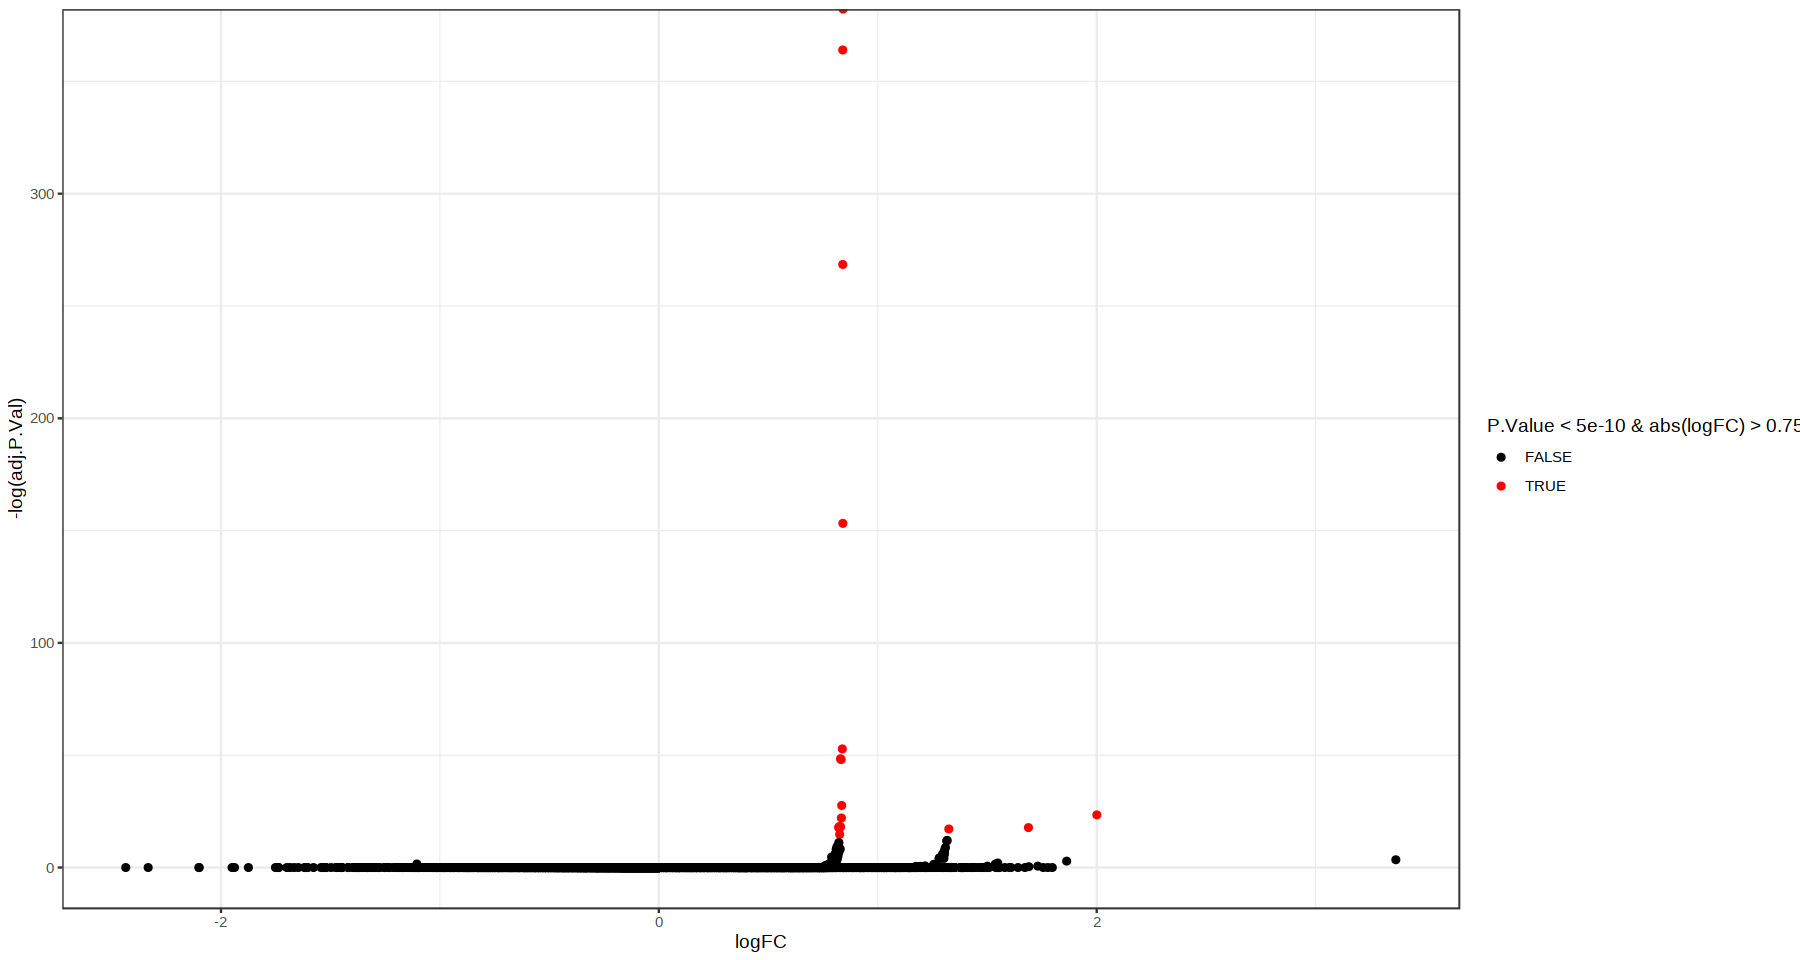

Warning message:
“Removed 22441 rows containing missing values (geom_point).”


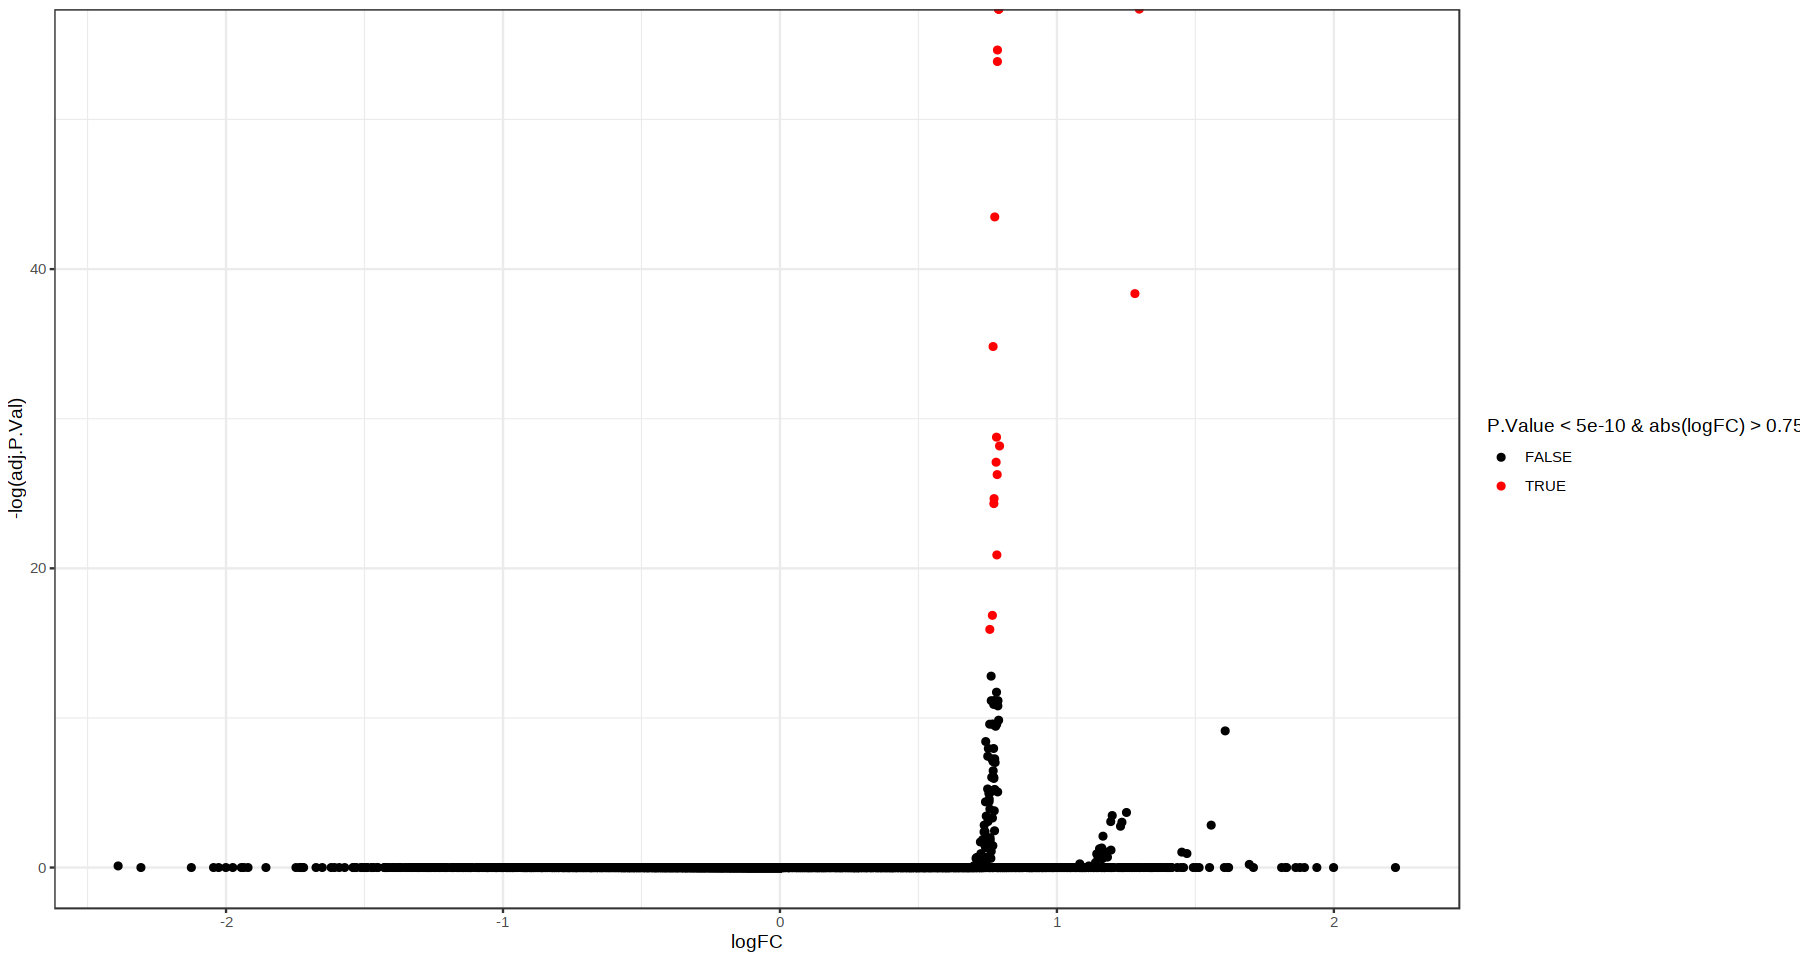

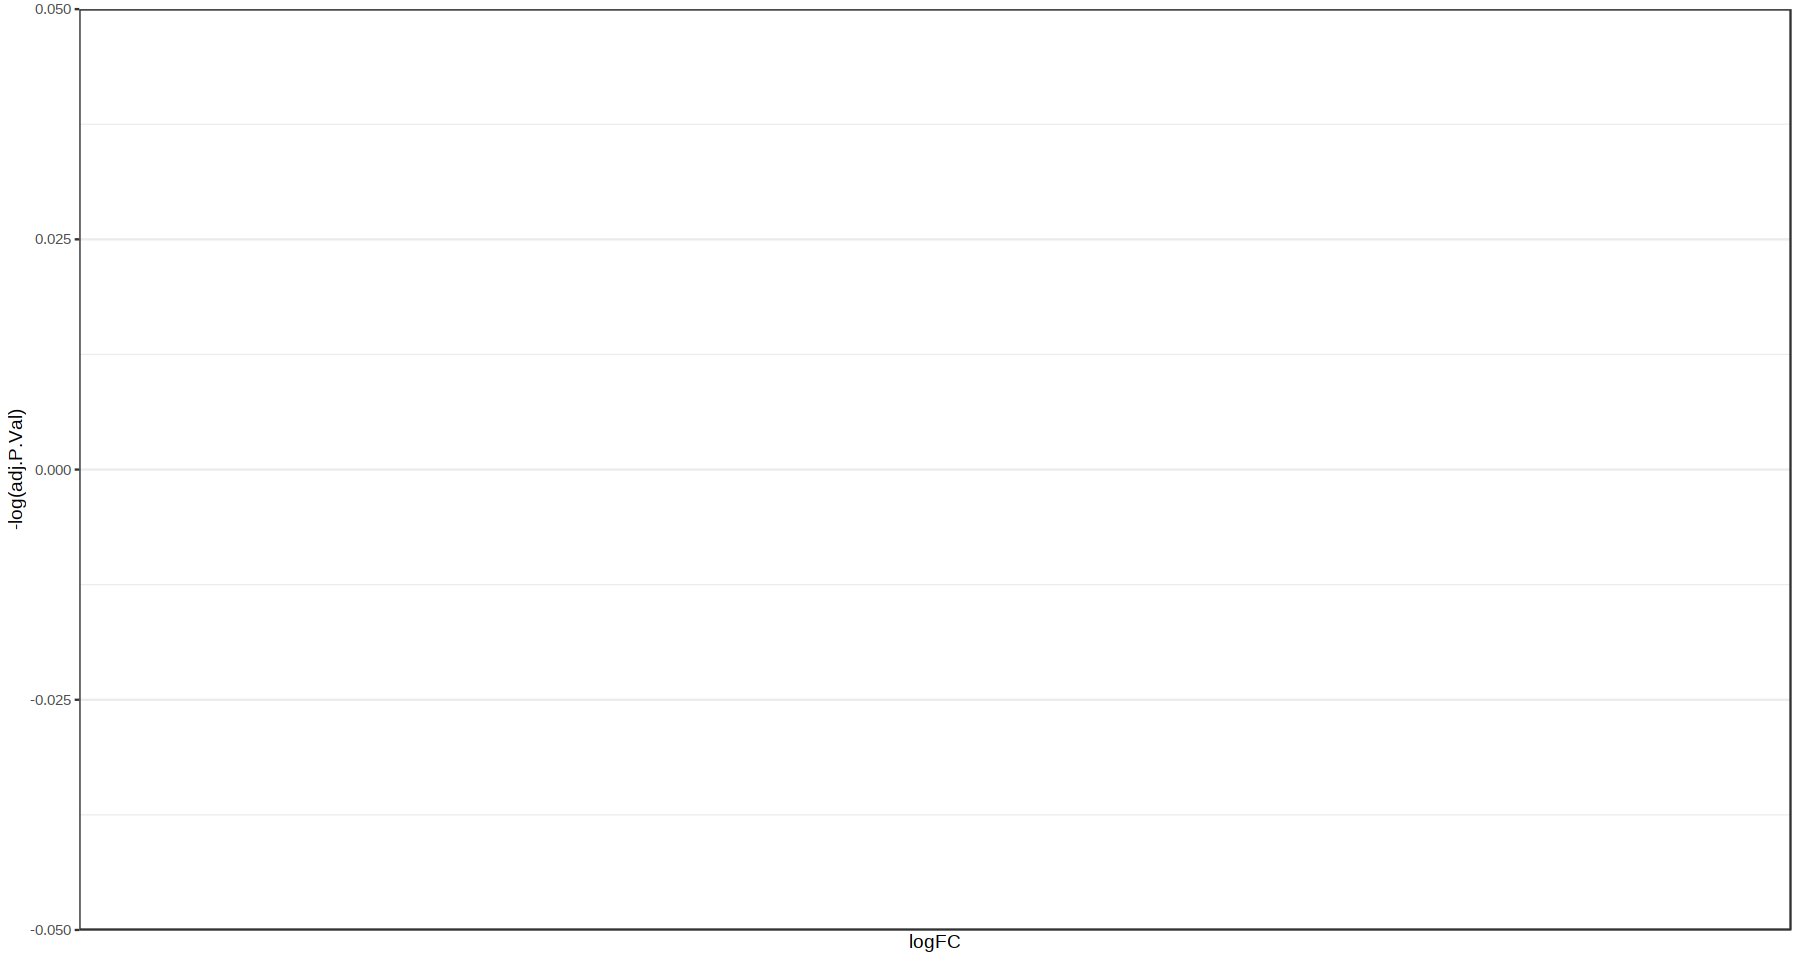

In [88]:
for(i in 1:length(test)){
p = ggplot(test[[i]], aes(logFC, -log(adj.P.Val), col= P.Value<5e-10 & abs(logFC)>0.75)) + 
    geom_point() +
    scale_color_manual(values=c('black', 'red')) + 
    theme_bw()
    print(p)
    }